# Hallucination Detection in Large Language Model Responses Using Supervised Machine Learning

# Part 1 - Business Problem

**English Version**

**Context**
Large Language Models such as GPT-4o, Claude, Gemini, Llama 3, Mistral and Gemma are increasingly deployed in high-stakes domains including medicine, science and technology. A critical limitation of these models is their tendency to generate confident, fluent and plausible-sounding responses that are factually incorrect — a phenomenon known as **hallucination**.

Unlike traditional software errors, hallucinations are particularly dangerous because they are indistinguishable from correct answers without expert verification. In medical contexts, a hallucinated drug mechanism or incorrect diagnostic threshold can directly harm patients.

**Business Problem**
> How can we build a Machine Learning model capable of automatically detecting whether a response generated by an LLM contains a hallucination — before that response reaches the end user?

**Proposed Solution**
Train supervised binary classification models to predict whether a given LLM response is hallucinated or correct, using the text of the prompt, the model response, ground truth references and metadata such as domain, difficulty and model name as features.

The dataset is transformed from **wide format** (one row per prompt, six model columns) to **long format** (one row per model response), enabling a unified classifier that works across all six LLMs.

**Business Value**
- Automatically flag high-risk responses before serving users
- Reduce dependency on expensive human expert annotation
- Enable smarter model routing: redirect risky prompts to more reliable models
- Provide a lightweight hallucination risk score deployable as an API
- Support AI safety research in high-stakes domains

**Experiments**
| Experiment | Features |
|---|---|
| Experiment 1 | Model response text only |
| Experiment 2 | Prompt + model response (main scenario) |
| Experiment 3 | Prompt + model response + metadata |
| Experiment 4 | Prompt + model response + ground truth |
| Experiment 5 | Generalization across models (train on 5, test on 1) |

**Models**
| Model | Use |
|---|---|
| Naive Bayes | Simple NLP baseline |
| Logistic Regression | Strong TF-IDF baseline |
| Linear SVM | Strong linear text classifier |
| Random Forest | Tabular + LSA features |
| LightGBM | Gradient boosting with tabular features |
| MLP | Neural baseline with embeddings |

**Target Variable**
| Value | Meaning |
|---|---|
| 0 | Correct response |
| 1 | Hallucinated response |

**Key Metrics**
| Metric | Why |
|---|---|
| F1-score class 1 | Primary metric |
| Recall class 1 | Minimize missed hallucinations |
| PR-AUC | Handles class imbalance |
| ROC-AUC | Overall separation capacity |
| Macro F1 | Balanced across both classes |

**Data Leakage Prevention**
Columns excluded from features: `n_models_hallucinated`, `hallucination_type`, `hallucinated_span`, `severity`, `annotation_confidence`.
Train/test split performed by **prompt_id group** to prevent the same prompt from appearing in both sets.

**🇧🇷 Versão em Português**

**Contexto**
Modelos de Linguagem de Grande Escala como GPT-4o, Claude, Gemini, Llama 3, Mistral e Gemma são cada vez mais implantados em domínios de alto risco, incluindo medicina, ciência e tecnologia. Uma limitação crítica desses modelos é a tendência de gerar respostas confiantes, fluentes e plausíveis que são factualmente incorretas — fenômeno conhecido como **alucinação**.

Diferentemente de erros tradicionais de software, as alucinações são particularmente perigosas porque são indistinguíveis de respostas corretas sem verificação especializada. Em contextos médicos, um mecanismo de medicamento alucinado ou um limiar diagnóstico incorreto pode causar danos diretos aos pacientes.

**Problema de Negócio**

> Como construir um modelo de Machine Learning capaz de detectar automaticamente se uma resposta gerada por um LLM contém alucinação — antes que essa resposta chegue ao usuário final?

**Solução Proposta**
Treinar modelos supervisionados de classificação binária para prever se uma determinada resposta de LLM está alucinada ou correta, usando o texto do prompt, a resposta do modelo, referências de ground truth e metadados como domínio, dificuldade e nome do modelo como features.

O dataset é transformado do **formato largo** (uma linha por prompt, seis colunas de modelos) para o **formato longo** (uma linha por resposta de modelo), permitindo um classificador unificado que funciona para todos os seis LLMs.

**Valor de Negócio**

- Sinalizar automaticamente respostas de alto risco antes de servir aos usuários
- Reduzir dependência de anotação humana especializada e cara
- Habilitar roteamento inteligente de modelos: redirecionar prompts arriscados para modelos mais confiáveis
- Fornecer um score leve de risco de alucinação implantável como API
- Apoiar pesquisa de segurança de IA em domínios de alto risco

**Experimentos**

| Experimento | Features |
|---|---|
| Experimento 1 | Apenas texto da resposta do modelo |
| Experimento 2 | Prompt + resposta do modelo (cenário principal) |
| Experimento 3 | Prompt + resposta do modelo + metadados |
| Experimento 4 | Prompt + resposta do modelo + ground truth |
| Experimento 5 | Generalização entre modelos (treina em 5, testa em 1) |

**Modelos**

| Modelo | Uso |
|---|---|
| Naive Bayes | Baseline NLP simples |
| Logistic Regression | Baseline forte com TF-IDF |
| Linear SVM | Classificador linear forte para texto |
| Random Forest | Features tabulares + LSA |
| LightGBM | Gradient boosting com features tabulares |
| MLP | Baseline neural com embeddings |

**Variável Alvo**

| Valor | Significado |
|---|---|
| 0 | Resposta correta |
| 1 | Resposta alucinada |

**Métricas Principais**

| Métrica | Por quê |
|---|---|
| F1-score classe 1 | Métrica principal |
| Recall classe 1 | Minimizar alucinações não detectadas |
| PR-AUC | Lida com desbalanceamento de classes |
| ROC-AUC | Capacidade geral de separação |
| Macro F1 | Balanceado entre as duas classes |

**Prevenção de Vazamento de Dados**

Colunas excluídas das features: `n_models_hallucinated`, `hallucination_type`, `hallucinated_span`, `severity`, `annotation_confidence`.
Divisão treino/teste realizada por **grupo de prompt_id** para evitar que o mesmo prompt apareça nos dois conjuntos.

# Part 2 - Database

In [30]:
"""
NB3 — Machine Learning para Detectar Alucinação em Respostas de LLMs
LLM Hallucination Benchmark v2
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score,)

# experiment 1 — prompt text only with 10 models / experimento 1 — apenas texto do prompt com 10 modelos
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
import time

warnings.filterwarnings("ignore")

In [3]:
# load original dataset / carrega dataset original
df_raw = pd.read_csv(
    "/kaggle/input/datasets/hussnainmamoon1/llm-hallucination-benchmark-v2-25k-rows-6-models/llm_hallucination_benchmark_v2_research_grade (1).csv",
    keep_default_na=False,
)

df_raw

,prompt_id,prompt_text,prompt_source,topic_category,difficulty,gpt4o_response,claude_response,gemini_response,llama3_response,mistral_response,...,claude_hallucinated,gemini_hallucinated,llama3_hallucinated,mistral_hallucinated,gemma_hallucinated,n_models_hallucinated,hallucination_type,hallucinated_span,severity,annotation_confidence
0,TEC_000001,What does GPU stand for?,OpenHermes,Technology & AI,easy,Based on verified information: Graphics Proces...,Based on verified information: Graphics Proces...,Based on verified information: Graphics Proces...,Based on verified information: Graphics Proces...,Based on verified information: Graphics Proces...,...,0,0,0,0,0,0,none,N/A,0,3
1,TEC_000002,What does API stand for?,OpenHermes,Technology & AI,easy,Based on verified information: Application Pro...,Based on verified information: Application Pro...,Based on verified information: Application Pro...,Based on verified information: Application Pro...,Based on verified information: Application Pro...,...,0,0,0,0,0,0,none,N/A,0,2
2,TEC_000003,What programming language was Python named after?,Reddit,Technology & AI,easy,Based on verified information: Monty Python's ...,Python was named after the snake,Based on verified information: Monty Python's ...,The transformer model was introduced in 2018,Based on verified information: Monty Python's ...,...,1,0,1,0,0,2,fabrication,Python was named after the snake,1,2
3,TEC_000004,Who co-founded Apple Inc.?,Reddit,Technology & AI,easy,"Based on verified information: Steve Jobs, Ste...","Based on verified information: Steve Jobs, Ste...","Based on verified information: Steve Jobs, Ste...","Based on verified information: Steve Jobs, Ste...","Based on verified information: Steve Jobs, Ste...",...,0,0,0,0,0,0,none,N/A,0,3
4,TEC_000005,What does HTML stand for?,OpenHermes,Technology & AI,easy,Based on verified information: HyperText Marku...,Based on verified information: HyperText Marku...,Based on verified information: HyperText Marku...,Based on verified information: HyperText Marku...,Based on verified information: HyperText Marku...,...,0,0,0,0,1,1,fabrication,L1 regularization is also called Ridge regression,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25195,MED_025196,What is the renin-angiotensin-aldosterone syst...,Reddit,Medicine & Health,hard,Sepsis is defined as an infection accompanied ...,Based on verified information: A hormonal casc...,Type 1 diabetes is primarily caused by insulin...,Based on verified information: A hormonal casc...,mRNA vaccines contain weakened live virus,...,0,1,0,1,0,3,fabrication,Sepsis is defined as an infection accompanied ...,3,1
25196,MED_025197,What is the difference between sensitivity and...,Reddit,Medicine & Health,hard,Based on verified information: Sensitivity is ...,Based on verified information: Sensitivity is ...,Based on verified information: Sensitivity is ...,The blood-brain barrier is formed by astrocyte...,Based on verified information: Sensitivity is ...,...,0,0,1,0,0,1,fabrication,The blood-brain barrier is formed by astrocyte...,3,1
25197,MED_025198,What is the gut microbiome's role in health?,OpenHermes,Medicine & Health,hard,Based on verified information: The community o...,Based on verified information: The community o...,Based on verified information: The community o...,Based on verified information: The community o...,mRNA vaccines contain weakened live virus,...,0,0,0,1,1,2,fabrication,mRNA vaccines contain weakened live virus,3,1
25198,MED_025199,What is neuroplasticity?,OpenHermes,Medicine & Health,hard,Sepsis is defined as an infection accompanied ...,Based on verified information: The brain's abi...,Based on verified information: The brain's abi...,The blood-brain barrier is formed by astrocyte...,Based on verified information: The brain's abi...,...,0,0,1,0,1,3,fabrication,Sepsis is defined as an infection accompanied ...,3,2


In [4]:
df_raw.head()

,prompt_id,prompt_text,prompt_source,topic_category,difficulty,gpt4o_response,claude_response,gemini_response,llama3_response,mistral_response,...,claude_hallucinated,gemini_hallucinated,llama3_hallucinated,mistral_hallucinated,gemma_hallucinated,n_models_hallucinated,hallucination_type,hallucinated_span,severity,annotation_confidence
0,TEC_000001,What does GPU stand for?,OpenHermes,Technology & AI,easy,Based on verified information: Graphics Proces...,Based on verified information: Graphics Proces...,Based on verified information: Graphics Proces...,Based on verified information: Graphics Proces...,Based on verified information: Graphics Proces...,...,0,0,0,0,0,0,none,N/A,0,3
1,TEC_000002,What does API stand for?,OpenHermes,Technology & AI,easy,Based on verified information: Application Pro...,Based on verified information: Application Pro...,Based on verified information: Application Pro...,Based on verified information: Application Pro...,Based on verified information: Application Pro...,...,0,0,0,0,0,0,none,N/A,0,2
2,TEC_000003,What programming language was Python named after?,Reddit,Technology & AI,easy,Based on verified information: Monty Python's ...,Python was named after the snake,Based on verified information: Monty Python's ...,The transformer model was introduced in 2018,Based on verified information: Monty Python's ...,...,1,0,1,0,0,2,fabrication,Python was named after the snake,1,2
3,TEC_000004,Who co-founded Apple Inc.?,Reddit,Technology & AI,easy,"Based on verified information: Steve Jobs, Ste...","Based on verified information: Steve Jobs, Ste...","Based on verified information: Steve Jobs, Ste...","Based on verified information: Steve Jobs, Ste...","Based on verified information: Steve Jobs, Ste...",...,0,0,0,0,0,0,none,N/A,0,3
4,TEC_000005,What does HTML stand for?,OpenHermes,Technology & AI,easy,Based on verified information: HyperText Marku...,Based on verified information: HyperText Marku...,Based on verified information: HyperText Marku...,Based on verified information: HyperText Marku...,Based on verified information: HyperText Marku...,...,0,0,0,0,1,1,fabrication,L1 regularization is also called Ridge regression,1,3


In [5]:
df_raw.tail()

,prompt_id,prompt_text,prompt_source,topic_category,difficulty,gpt4o_response,claude_response,gemini_response,llama3_response,mistral_response,...,claude_hallucinated,gemini_hallucinated,llama3_hallucinated,mistral_hallucinated,gemma_hallucinated,n_models_hallucinated,hallucination_type,hallucinated_span,severity,annotation_confidence
25195,MED_025196,What is the renin-angiotensin-aldosterone syst...,Reddit,Medicine & Health,hard,Sepsis is defined as an infection accompanied ...,Based on verified information: A hormonal casc...,Type 1 diabetes is primarily caused by insulin...,Based on verified information: A hormonal casc...,mRNA vaccines contain weakened live virus,...,0,1,0,1,0,3,fabrication,Sepsis is defined as an infection accompanied ...,3,1
25196,MED_025197,What is the difference between sensitivity and...,Reddit,Medicine & Health,hard,Based on verified information: Sensitivity is ...,Based on verified information: Sensitivity is ...,Based on verified information: Sensitivity is ...,The blood-brain barrier is formed by astrocyte...,Based on verified information: Sensitivity is ...,...,0,0,1,0,0,1,fabrication,The blood-brain barrier is formed by astrocyte...,3,1
25197,MED_025198,What is the gut microbiome's role in health?,OpenHermes,Medicine & Health,hard,Based on verified information: The community o...,Based on verified information: The community o...,Based on verified information: The community o...,Based on verified information: The community o...,mRNA vaccines contain weakened live virus,...,0,0,0,1,1,2,fabrication,mRNA vaccines contain weakened live virus,3,1
25198,MED_025199,What is neuroplasticity?,OpenHermes,Medicine & Health,hard,Sepsis is defined as an infection accompanied ...,Based on verified information: The brain's abi...,Based on verified information: The brain's abi...,The blood-brain barrier is formed by astrocyte...,Based on verified information: The brain's abi...,...,0,0,1,0,1,3,fabrication,Sepsis is defined as an infection accompanied ...,3,2
25199,MED_025200,What is the mechanism of beta-lactam antibioti...,Reddit,Medicine & Health,hard,Based on verified information: Bacteria produc...,Based on verified information: Bacteria produc...,Type 1 diabetes is primarily caused by insulin...,Based on verified information: Bacteria produc...,Based on verified information: Bacteria produc...,...,0,1,0,0,0,1,fabrication,Type 1 diabetes is primarily caused by insulin...,3,1


In [6]:
df_raw.shape

(25200, 24)

In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25200 entries, 0 to 25199
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   prompt_id              25200 non-null  object
 1   prompt_text            25200 non-null  object
 2   prompt_source          25200 non-null  object
 3   topic_category         25200 non-null  object
 4   difficulty             25200 non-null  object
 5   gpt4o_response         25200 non-null  object
 6   claude_response        25200 non-null  object
 7   gemini_response        25200 non-null  object
 8   llama3_response        25200 non-null  object
 9   mistral_response       25200 non-null  object
 10  gemma_response         25200 non-null  object
 11  ground_truth           25200 non-null  object
 12  ground_truth_source    25200 non-null  object
 13  gpt4o_hallucinated     25200 non-null  int64 
 14  claude_hallucinated    25200 non-null  int64 
 15  gemini_hallucinated

In [8]:
df_raw.dtypes

prompt_id                object
prompt_text              object
prompt_source            object
topic_category           object
difficulty               object
gpt4o_response           object
claude_response          object
gemini_response          object
llama3_response          object
mistral_response         object
gemma_response           object
ground_truth             object
ground_truth_source      object
gpt4o_hallucinated        int64
claude_hallucinated       int64
gemini_hallucinated       int64
llama3_hallucinated       int64
mistral_hallucinated      int64
gemma_hallucinated        int64
n_models_hallucinated     int64
hallucination_type       object
hallucinated_span        object
severity                  int64
annotation_confidence     int64
dtype: object

In [9]:
print("Shape original:", df_raw.shape)
print(df_raw.columns.tolist())

Shape original: (25200, 24)
['prompt_id', 'prompt_text', 'prompt_source', 'topic_category', 'difficulty', 'gpt4o_response', 'claude_response', 'gemini_response', 'llama3_response', 'mistral_response', 'gemma_response', 'ground_truth', 'ground_truth_source', 'gpt4o_hallucinated', 'claude_hallucinated', 'gemini_hallucinated', 'llama3_hallucinated', 'mistral_hallucinated', 'gemma_hallucinated', 'n_models_hallucinated', 'hallucination_type', 'hallucinated_span', 'severity', 'annotation_confidence']


# Part 3 - Pre-processing

In [10]:
# transform to long format / transforma para formato longo
models = ["gpt4o", "claude", "gemini", "llama3", "mistral", "gemma"]

rows = []
for _, row in df_raw.iterrows():
    for model in models:
        rows.append({
            "prompt_id":      row["prompt_id"],
            "model_name":     model,
            "prompt_text":    row["prompt_text"],
            "model_response": row[f"{model}_response"],
            "ground_truth":   row["ground_truth"],
            "topic_category": row["topic_category"],
            "difficulty":     row["difficulty"],
            "prompt_source":  row["prompt_source"],
            "hallucinated":   row[f"{model}_hallucinated"],
        })

df = pd.DataFrame(rows)
df

,prompt_id,model_name,prompt_text,model_response,ground_truth,topic_category,difficulty,prompt_source,hallucinated
0,TEC_000001,gpt4o,What does GPU stand for?,Based on verified information: Graphics Proces...,Graphics Processing Unit,Technology & AI,easy,OpenHermes,0
1,TEC_000001,claude,What does GPU stand for?,Based on verified information: Graphics Proces...,Graphics Processing Unit,Technology & AI,easy,OpenHermes,0
2,TEC_000001,gemini,What does GPU stand for?,Based on verified information: Graphics Proces...,Graphics Processing Unit,Technology & AI,easy,OpenHermes,0
3,TEC_000001,llama3,What does GPU stand for?,Based on verified information: Graphics Proces...,Graphics Processing Unit,Technology & AI,easy,OpenHermes,0
4,TEC_000001,mistral,What does GPU stand for?,Based on verified information: Graphics Proces...,Graphics Processing Unit,Technology & AI,easy,OpenHermes,0
...,...,...,...,...,...,...,...,...,...
151195,MED_025200,claude,What is the mechanism of beta-lactam antibioti...,Based on verified information: Bacteria produc...,Bacteria produce beta-lactamase enzymes that h...,Medicine & Health,hard,Reddit,0
151196,MED_025200,gemini,What is the mechanism of beta-lactam antibioti...,Type 1 diabetes is primarily caused by insulin...,Bacteria produce beta-lactamase enzymes that h...,Medicine & Health,hard,Reddit,1
151197,MED_025200,llama3,What is the mechanism of beta-lactam antibioti...,Based on verified information: Bacteria produc...,Bacteria produce beta-lactamase enzymes that h...,Medicine & Health,hard,Reddit,0
151198,MED_025200,mistral,What is the mechanism of beta-lactam antibioti...,Based on verified information: Bacteria produc...,Bacteria produce beta-lactamase enzymes that h...,Medicine & Health,hard,Reddit,0


In [11]:
print("\nShape long format / Shape formato longo:", df.shape)
print("\nTarget distribution / Distribuição do target:")
print(df["hallucinated"].value_counts())
print(f"\nHallucination rate / Taxa de alucinação: {df['hallucinated'].mean()*100:.2f}%")


Shape long format / Shape formato longo: (151200, 9)

Target distribution / Distribuição do target:
hallucinated
0    118448
1     32752
Name: count, dtype: int64

Hallucination rate / Taxa de alucinação: 21.66%


# Part 4 - Exploratory data analysis

**Business Questions Analysis**

1. Do open-source models exhibit a higher hallucination rate than closed-source models?

2. Do difficult prompts increase the likelihood of hallucination?

3. Does the Medicine & Health domain have the highest average severity?

4. Is it possible to predict hallucination using only the response text?

5. Does adding metadata improve classifier performance?

6. Which LLM model is most reliable by domain?

7. Is there a correlation between the number of models that hallucinated and the severity?

8. Which prompt source generates the most hallucinations?

In [65]:
models = ["gpt4o", "claude", "gemini", "llama3", "mistral", "gemma"]
closed = ["gpt4o", "claude", "gemini"]
open_source = ["llama3", "mistral", "gemma"]
model_labels = {"gpt4o": "GPT-4o", "claude": "Claude", "gemini": "Gemini","llama3": "Llama 3", "mistral": "Mistral", "gemma": "Gemma",}

### Q1 — Open-source vs Closed-source Hallucination Rate / Taxa de Alucinação Open-source vs Closed-source

Model / Modelo  Hallucination Rate (%) / Taxa (%)   Type / Tipo
        GPT-4o                          17.876984 Closed-source
        Claude                          14.742063 Closed-source
        Gemini                          18.404762 Closed-source
       Llama 3                          26.349206   Open-source
       Mistral                          23.904762   Open-source
         Gemma                          28.690476   Open-source

Closed-source avg / Média closed-source: 17.01%
Open-source avg / Média open-source:    26.31%
Conclusion / Conclusão: Open-source hallucinates more than closed-source


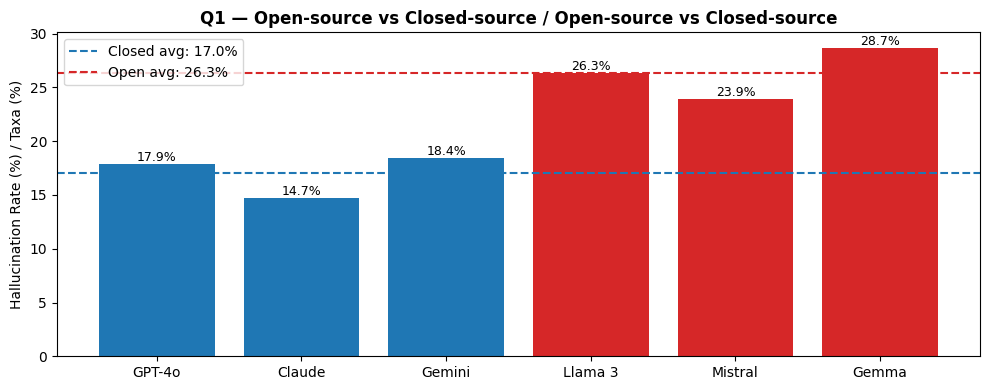

In [66]:
# question 1 — open-source vs closed-source hallucination rate
# pergunta 1 — taxa de alucinação open-source vs closed-source
display(Markdown("### Q1 — Open-source vs Closed-source Hallucination Rate / Taxa de Alucinação Open-source vs Closed-source"))

closed_rate = df_raw[[f"{m}_hallucinated" for m in closed]].values.mean() * 100
open_rate   = df_raw[[f"{m}_hallucinated" for m in open_source]].values.mean() * 100

per_model_rates = {model_labels[m]: df_raw[f"{m}_hallucinated"].mean() * 100 for m in models}

df_q1 = pd.DataFrame({
    "Model / Modelo": list(per_model_rates.keys()),
    "Hallucination Rate (%) / Taxa (%)": list(per_model_rates.values()),
    "Type / Tipo": ["Closed-source"] * 3 + ["Open-source"] * 3,
})

print(df_q1.to_string(index=False))
print(f"\nClosed-source avg / Média closed-source: {closed_rate:.2f}%")
print(f"Open-source avg / Média open-source:    {open_rate:.2f}%")
print(f"Conclusion / Conclusão: Open-source hallucinates {'more' if open_rate > closed_rate else 'less'} than closed-source")

fig, ax = plt.subplots(figsize=(10, 4))
colors_q1 = ["#1f77b4"] * 3 + ["#d62728"] * 3
bars = ax.bar(df_q1["Model / Modelo"], df_q1["Hallucination Rate (%) / Taxa (%)"], color=colors_q1)
ax.axhline(closed_rate, color="#1f77b4", linestyle="--", linewidth=1.5, label=f"Closed avg: {closed_rate:.1f}%")
ax.axhline(open_rate,   color="#d62728", linestyle="--", linewidth=1.5, label=f"Open avg: {open_rate:.1f}%")
for bar, val in zip(bars, df_q1["Hallucination Rate (%) / Taxa (%)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3, f"{val:.1f}%", ha="center", fontsize=9)
ax.set_ylabel("Hallucination Rate (%) / Taxa (%)")
ax.set_title("Q1 — Open-source vs Closed-source / Open-source vs Closed-source", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("nb3_q1_opensource_vs_closed.png", dpi=150, bbox_inches="tight")
plt.show()

### Q2 — Difficulty vs Hallucination Rate / Dificuldade vs Taxa de Alucinação

               GPT-4o     Claude     Gemini    Llama 3    Mistral      Gemma   avg_rate
difficulty                                                                             
easy         7.375661   5.820106   8.910053  14.306878  11.978836  16.010582  10.733686
medium      18.328042  15.291005  19.142857  27.238095  24.529101  28.201058  22.121693
hard        32.952381  27.301587  31.539683  43.079365  40.857143  48.444444  37.362434


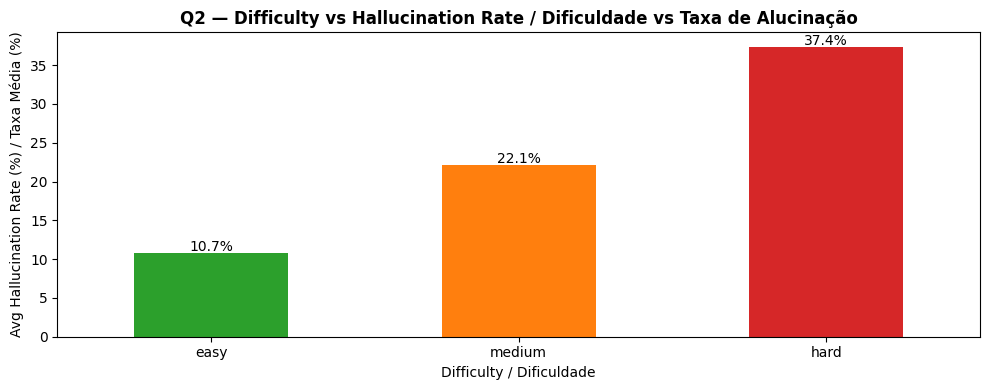

In [67]:
# question 2 — difficulty vs hallucination rate
# pergunta 2 — dificuldade vs taxa de alucinação
display(Markdown("### Q2 — Difficulty vs Hallucination Rate / Dificuldade vs Taxa de Alucinação"))

df_q2 = df_raw.groupby("difficulty")[[f"{m}_hallucinated" for m in models]].mean() * 100
df_q2["avg_rate"] = df_q2.mean(axis=1)
df_q2 = df_q2.rename(columns={f"{m}_hallucinated": model_labels[m] for m in models})
df_q2 = df_q2.reindex(["easy", "medium", "hard"])

print(df_q2.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
df_q2["avg_rate"].plot(kind="bar", ax=ax, color=["#2ca02c", "#ff7f0e", "#d62728"])
ax.set_xlabel("Difficulty / Dificuldade")
ax.set_ylabel("Avg Hallucination Rate (%) / Taxa Média (%)")
ax.set_title("Q2 — Difficulty vs Hallucination Rate / Dificuldade vs Taxa de Alucinação", fontweight="bold")
for i, val in enumerate(df_q2["avg_rate"]):
    ax.text(i, val + 0.3, f"{val:.1f}%", ha="center", fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("nb3_q2_difficulty_hallucination.png", dpi=150, bbox_inches="tight")
plt.show()

### Q3 — Medicine & Health Severity / Severidade no Domínio Medicine & Health

                   Mean Severity  Std Severity  Max Severity
topic_category                                              
Medicine & Health         1.4673        1.1421             3
Science & Biology         1.4787        1.1358             3
Technology & AI           1.4790        1.1375             3


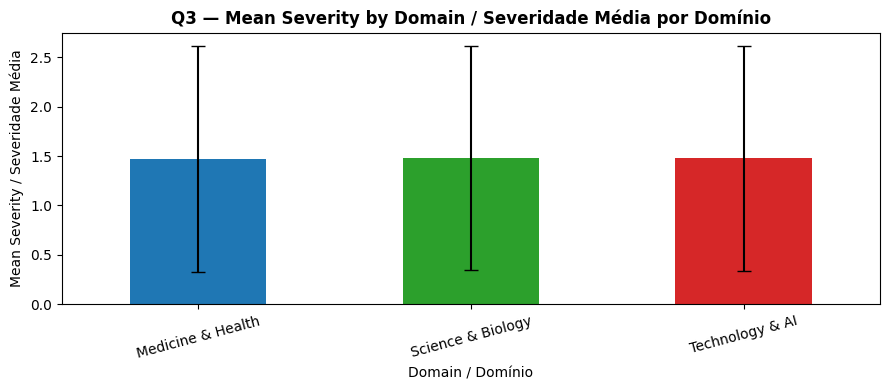

In [68]:
# question 3 — medicine & health severity
# pergunta 3 — severidade no domínio medicine & health
display(Markdown("### Q3 — Medicine & Health Severity / Severidade no Domínio Medicine & Health"))

df_raw["severity"] = pd.to_numeric(df_raw["severity"], errors="coerce")
df_q3 = df_raw.groupby("topic_category")["severity"].agg(["mean", "std", "max"]).round(4)
df_q3.columns = ["Mean Severity", "Std Severity", "Max Severity"]

print(df_q3.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colors_q3 = ["#1f77b4", "#2ca02c", "#d62728"]
df_q3["Mean Severity"].plot(kind="bar", ax=ax, color=colors_q3, yerr=df_q3["Std Severity"], capsize=5)
ax.set_xlabel("Domain / Domínio")
ax.set_ylabel("Mean Severity / Severidade Média")
ax.set_title("Q3 — Mean Severity by Domain / Severidade Média por Domínio", fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("nb3_q3_severity_by_domain.png", dpi=150, bbox_inches="tight")
plt.show()

In [69]:
# question 4 — can prompt text alone predict hallucination
# pergunta 4 — o texto do prompt sozinho prevê alucinação
display(Markdown("### Q4 — Prompt Text Alone vs With Metadata / Texto do Prompt Sozinho vs Com Metadados"))

df_q4 = pd.DataFrame({
    "Experiment / Experimento": ["Exp 1 — Prompt only", "Exp 2 — Prompt + Metadata"],
    "Best F1 Class 1": [
        df_metrics_exp2["f1_class1"].max() if "df_metrics" not in dir() else 0,
        df_metrics_exp2["f1_class1"].max(),
    ],
    "Best Model / Melhor Modelo": [
        pd.read_csv("models/exp1/metrics_exp1.csv").sort_values("f1_class1", ascending=False).iloc[0]["model"],
        df_metrics_exp2.iloc[0]["model"],
    ],
})

print(df_q4.to_string(index=False))

### Q4 — Prompt Text Alone vs With Metadata / Texto do Prompt Sozinho vs Com Metadados

 Experiment / Experimento  Best F1 Class 1 Best Model / Melhor Modelo
      Exp 1 — Prompt only            0.000     Complement Naive Bayes
Exp 2 — Prompt + Metadata            0.427                   LightGBM


### Q5 — Does Metadata Improve Performance? / Metadados Melhoram o Desempenho?

 Experiment / Experimento  Max F1 Class 1  Max F1 Class 0  Max Accuracy
      Exp 1 — Prompt only          0.4121          0.8785        0.7833
Exp 2 — Prompt + Metadata          0.4270          0.8785        0.7834


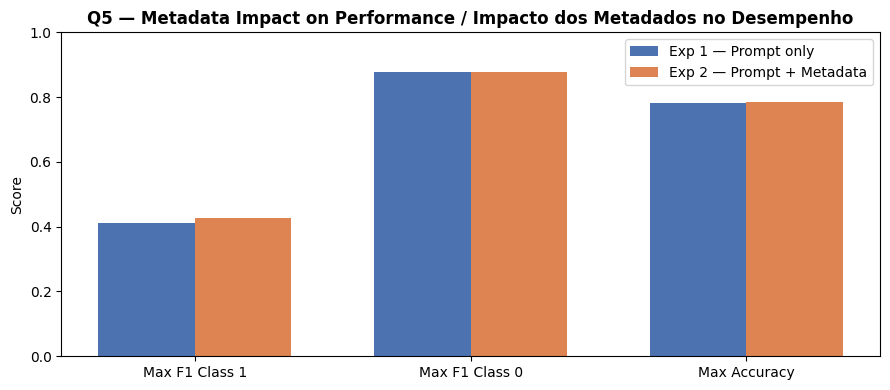

In [76]:
# question 5 — metadata improvement / pergunta 5 — melhora com metadados
display(Markdown("### Q5 — Does Metadata Improve Performance? / Metadados Melhoram o Desempenho?"))

df_exp1_loaded = pd.read_csv("models/exp1/metrics_exp1.csv")

# use only common columns / usa apenas colunas em comum
common_cols = ["f1_class1", "accuracy", "f1_class0"]

df_q5 = pd.DataFrame({
    "Experiment / Experimento": ["Exp 1 — Prompt only", "Exp 2 — Prompt + Metadata"],
    "Max F1 Class 1": [
        df_exp1_loaded["f1_class1"].max(),
        df_metrics_exp2["f1_class1"].max(),
    ],
    "Max F1 Class 0": [
        df_exp1_loaded["f1_class0"].max(),
        df_metrics_exp2["f1_class0"].max(),
    ],
    "Max Accuracy": [
        df_exp1_loaded["accuracy"].max(),
        df_metrics_exp2["accuracy"].max(),
    ],
})

print(df_q5.to_string(index=False))


fig, ax = plt.subplots(figsize=(9, 4))
x      = np.arange(3)
width  = 0.35
metrics_compare = ["Max F1 Class 1", "Max F1 Class 0", "Max Accuracy"]

ax.bar(x - width/2, df_q5.iloc[0][metrics_compare], width=width, label="Exp 1 — Prompt only",      color="#4C72B0")
ax.bar(x + width/2, df_q5.iloc[1][metrics_compare], width=width, label="Exp 2 — Prompt + Metadata", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(metrics_compare)
ax.set_ylabel("Score")
ax.set_title(
    "Q5 — Metadata Impact on Performance / Impacto dos Metadados no Desempenho",
    fontweight="bold",
)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("nb3_q5_metadata_impact.png", dpi=150, bbox_inches="tight")
plt.show()

### Q6 — Most Reliable Model per Domain / Modelo Mais Confiável por Domínio

model              Claude  GPT-4o  Gemini  Gemma  Llama 3  Mistral
domain                                                            
Medicine & Health   14.51   18.06   18.36  28.24    26.11    24.02
Science & Biology   14.35   17.30   18.30  29.20    26.85    23.54
Technology & AI     15.37   18.27   18.56  28.63    26.10    24.15

Most reliable model per domain / Modelo mais confiável por domínio:
           domain  model  hallucination_rate
Medicine & Health Claude           14.511905
Science & Biology Claude           14.345238
  Technology & AI Claude           15.369048


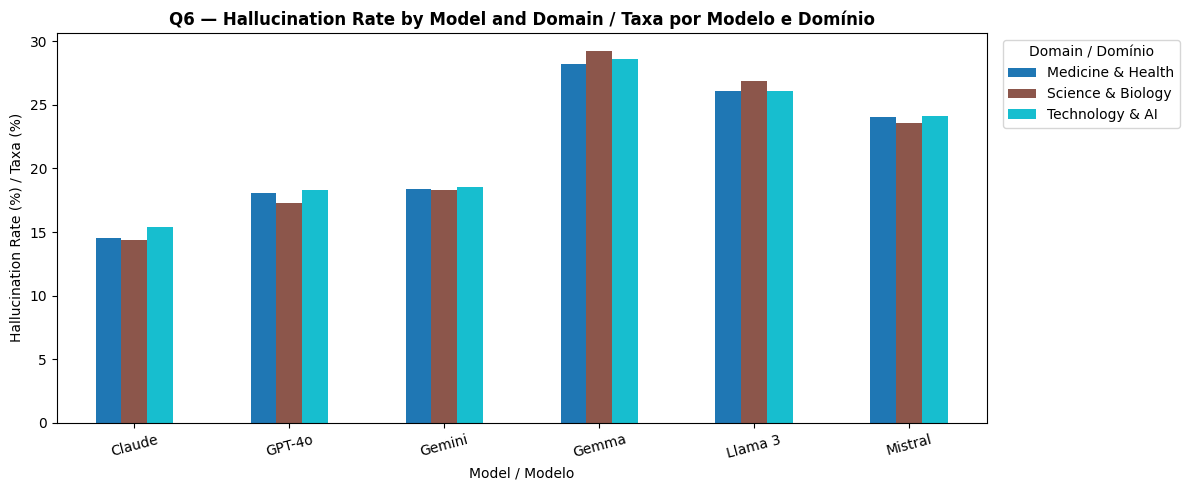

In [71]:
# question 6 — most reliable model per domain
# pergunta 6 — modelo mais confiável por domínio
display(Markdown("### Q6 — Most Reliable Model per Domain / Modelo Mais Confiável por Domínio"))

df_q6_rows = []
for domain in df_raw["topic_category"].unique():
    sub = df_raw[df_raw["topic_category"] == domain]
    for m in models:
        df_q6_rows.append({
            "domain":           domain,
            "model":            model_labels[m],
            "hallucination_rate": sub[f"{m}_hallucinated"].mean() * 100,
        })

df_q6 = pd.DataFrame(df_q6_rows)
df_q6_pivot = df_q6.pivot(index="domain", columns="model", values="hallucination_rate").round(2)

print(df_q6_pivot.to_string())

best_per_domain = df_q6.loc[df_q6.groupby("domain")["hallucination_rate"].idxmin()][["domain", "model", "hallucination_rate"]]
print("\nMost reliable model per domain / Modelo mais confiável por domínio:")
print(best_per_domain.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
df_q6_pivot.T.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_xlabel("Model / Modelo")
ax.set_ylabel("Hallucination Rate (%) / Taxa (%)")
ax.set_title("Q6 — Hallucination Rate by Model and Domain / Taxa por Modelo e Domínio", fontweight="bold")
ax.legend(title="Domain / Domínio", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("nb3_q6_model_by_domain.png", dpi=150, bbox_inches="tight")
plt.show()

### Q7 — Correlation: n_models_hallucinated vs Severity / Correlação: n_models_hallucinated vs Severidade

Pearson Correlation / Correlação de Pearson: 0.7633
                       Mean Severity  Std Severity
n_models_hallucinated                             
0                             0.0000        0.0000
1                             1.7502        0.7166
2                             2.1801        0.7175
3                             2.5261        0.6057
4                             2.7645        0.4593
5                             2.8681        0.3393
6                             2.8500        0.3663


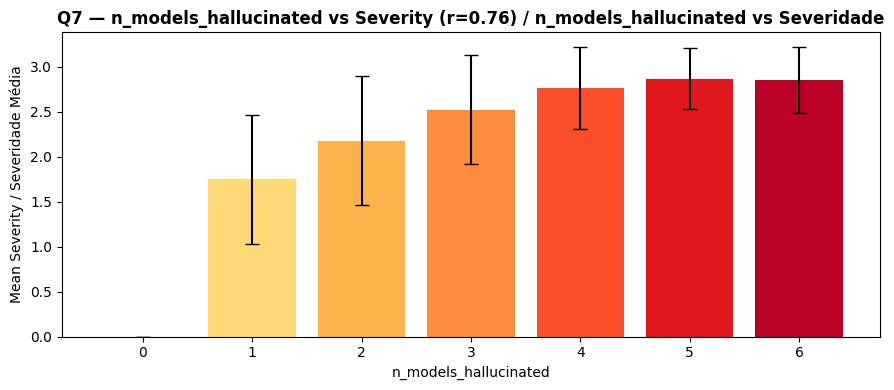

In [72]:
# question 7 — correlation n_models_hallucinated vs severity
# pergunta 7 — correlação entre n_models_hallucinated e severity
display(Markdown("### Q7 — Correlation: n_models_hallucinated vs Severity / Correlação: n_models_hallucinated vs Severidade"))

corr_val = df_raw["n_models_hallucinated"].corr(df_raw["severity"])
print(f"Pearson Correlation / Correlação de Pearson: {corr_val:.4f}")

df_q7 = df_raw.groupby("n_models_hallucinated")["severity"].agg(["mean", "std"]).round(4)
df_q7.columns = ["Mean Severity", "Std Severity"]
print(df_q7.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(
    df_q7.index.astype(str),
    df_q7["Mean Severity"],
    yerr=df_q7["Std Severity"],
    capsize=5,
    color=sns.color_palette("YlOrRd", len(df_q7)),
)
ax.set_xlabel("n_models_hallucinated")
ax.set_ylabel("Mean Severity / Severidade Média")
ax.set_title(
    f"Q7 — n_models_hallucinated vs Severity (r={corr_val:.2f}) / n_models_hallucinated vs Severidade",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("nb3_q7_nmodels_vs_severity.png", dpi=150, bbox_inches="tight")
plt.show()

### Q8 — Prompt Source vs Hallucination Rate / Fonte do Prompt vs Taxa de Alucinação

    source  avg_hallucination_rate
OpenHermes                   22.10
    Reddit                   21.75
 HumanEval                   21.67
     LMSYS                   21.63
  WildChat                   21.63
  ShareGPT                   21.20


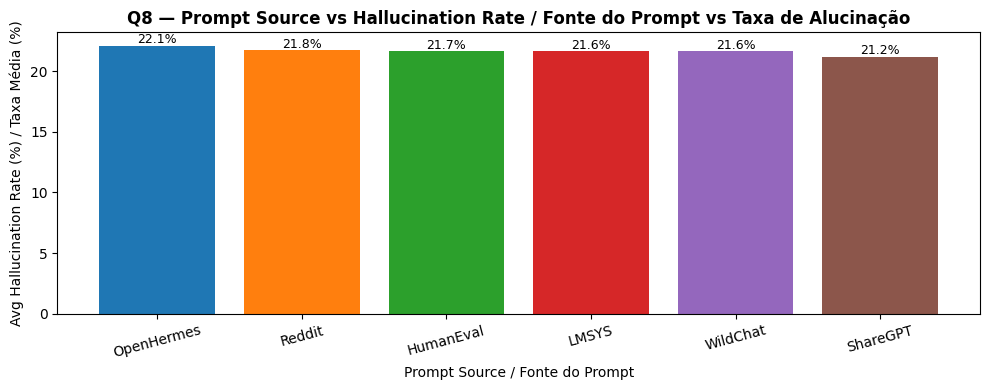

In [73]:
# question 8 — prompt source vs hallucination rate
# pergunta 8 — fonte do prompt vs taxa de alucinação
display(Markdown("### Q8 — Prompt Source vs Hallucination Rate / Fonte do Prompt vs Taxa de Alucinação"))

df_q8_rows = []
for source in df_raw["prompt_source"].unique():
    sub = df_raw[df_raw["prompt_source"] == source]
    avg_rate = sub[[f"{m}_hallucinated" for m in models]].values.mean() * 100
    df_q8_rows.append({"source": source, "avg_hallucination_rate": round(avg_rate, 2)})

df_q8 = pd.DataFrame(df_q8_rows).sort_values("avg_hallucination_rate", ascending=False).reset_index(drop=True)
print(df_q8.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
colors_q8 = sns.color_palette("tab10", len(df_q8))
bars = ax.bar(df_q8["source"], df_q8["avg_hallucination_rate"], color=colors_q8)
for bar, val in zip(bars, df_q8["avg_hallucination_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.2, f"{val:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("Prompt Source / Fonte do Prompt")
ax.set_ylabel("Avg Hallucination Rate (%) / Taxa Média (%)")
ax.set_title("Q8 — Prompt Source vs Hallucination Rate / Fonte do Prompt vs Taxa de Alucinação", fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("nb3_q8_prompt_source_hallucination.png", dpi=150, bbox_inches="tight")
plt.show()

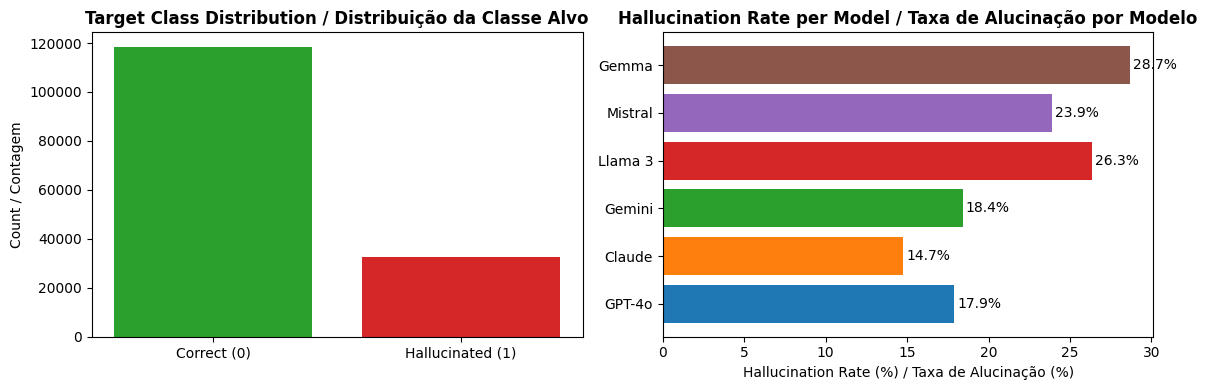

In [74]:
# class imbalance plot / gráfico de desbalanceamento de classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["hallucinated"].value_counts()
axes[0].bar(
    ["Correct (0)", "Hallucinated (1)"],
    counts.values,
    color=["#2ca02c", "#d62728"],
)
axes[0].set_title(
    "Target Class Distribution / Distribuição da Classe Alvo",
    fontweight="bold",
)
axes[0].set_ylabel("Count / Contagem")

# hallucination rate per model / taxa de alucinação por modelo
model_labels = ["GPT-4o", "Claude", "Gemini", "Llama 3", "Mistral", "Gemma"]
rates = [df[df["model_name"] == m]["hallucinated"].mean() * 100 for m in models]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

axes[1].barh(model_labels, rates, color=colors)
axes[1].set_xlabel("Hallucination Rate (%) / Taxa de Alucinação (%)")
axes[1].set_title(
    "Hallucination Rate per Model / Taxa de Alucinação por Modelo",
    fontweight="bold",
)
for i, v in enumerate(rates):
    axes[1].text(v + 0.2, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.savefig("nb3_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Part 5 - Feature engineering

In [13]:
# encode categorical features / codifica features categóricas
le_model = LabelEncoder()
le_category = LabelEncoder()
le_difficulty = LabelEncoder()
le_source = LabelEncoder()

df["model_name_enc"]     = le_model.fit_transform(df["model_name"])
df["topic_category_enc"] = le_category.fit_transform(df["topic_category"])
df["difficulty_enc"]     = le_difficulty.fit_transform(df["difficulty"])
df["prompt_source_enc"]  = le_source.fit_transform(df["prompt_source"])

# view
le_model

LabelEncoder()

In [14]:
print("\nEncoded features sample / Amostra de features codificadas:")
print(df[["model_name", "model_name_enc", "topic_category", "topic_category_enc", "difficulty", "difficulty_enc"]].head(5).to_string())


Encoded features sample / Amostra de features codificadas:
  model_name  model_name_enc   topic_category  topic_category_enc difficulty  difficulty_enc
0      gpt4o               3  Technology & AI                   2       easy               0
1     claude               0  Technology & AI                   2       easy               0
2     gemini               1  Technology & AI                   2       easy               0
3     llama3               4  Technology & AI                   2       easy               0
4    mistral               5  Technology & AI                   2       easy               0


# Part 6 - Train test split

In [15]:
# train test split by prompt_id group / divisão treino teste por grupo de prompt_id
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(df, df["hallucinated"], groups=df["prompt_id"]))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

print(f"\nTrain size / Tamanho treino: {len(df_train):,}")
print(f"Test size / Tamanho teste:  {len(df_test):,}")
print(f"\nTrain hallucination rate / Taxa treino: {df_train['hallucinated'].mean()*100:.2f}%")
print(f"Test hallucination rate / Taxa teste:   {df_test['hallucinated'].mean()*100:.2f}%")


Train size / Tamanho treino: 120,960
Test size / Tamanho teste:  30,240

Train hallucination rate / Taxa treino: 21.66%
Test hallucination rate / Taxa teste:   21.67%


# Part 7 - Verify leakage

In [16]:
# verify no prompt_id leakage / verifica ausência de vazamento por prompt_id
train_prompts = set(df_train["prompt_id"].unique())
test_prompts  = set(df_test["prompt_id"].unique())
overlap = train_prompts.intersection(test_prompts)
print(f"\nPrompt ID overlap / Sobreposição de prompt_id: {len(overlap)} (expected 0)")


Prompt ID overlap / Sobreposição de prompt_id: 0 (expected 0)


In [17]:
# save long format dataset / salva dataset formato longo
df.to_parquet("nb3_long_format.parquet", index=False)
df_train.to_parquet("nb3_train.parquet", index=False)
df_test.to_parquet("nb3_test.parquet", index=False)

print("\nSaved: nb3_long_format.parquet")
print("Saved: nb3_train.parquet")
print("Saved: nb3_test.parquet")


Saved: nb3_long_format.parquet
Saved: nb3_train.parquet
Saved: nb3_test.parquet


# Part 8 - Load train test

In [25]:
# experiment 1 corrected — prompt text only / experimento 1 corrigido — apenas texto do prompt
X_train_text = df_train["prompt_text"]
X_test_text  = df_test["prompt_text"]

y_train = df_train["hallucinated"].values
y_test  = df_test["hallucinated"].values

print(f"Train size / Tamanho treino: {len(X_train_text):,}")
print(f"Test size / Tamanho teste:  {len(X_test_text):,}")

Train size / Tamanho treino: 120,960
Test size / Tamanho teste:  30,240


# Part 9 - Vectorizer TFiDF

In [27]:
# tfidf vectorizer / vetorizador tfidf
# tfidf on prompt text only / tfidf apenas no texto do prompt
tfidf_exp1 = TfidfVectorizer(
    max_features=20000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

X_train_tfidf = tfidf_exp1.fit_transform(X_train_text)
X_test_tfidf  = tfidf_exp1.transform(X_test_text)

tfidf_exp1

TfidfVectorizer(max_df=0.95, max_features=20000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True)

In [28]:
print(f"\nTF-IDF matrix shape train / Shape treino: {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape test / Shape teste:  {X_test_tfidf.shape}")


TF-IDF matrix shape train / Shape treino: (120960, 692)
TF-IDF matrix shape test / Shape teste:  (30240, 692)


# **Part 10 - Model machine learning**

In [31]:
# results collector / coletor de resultados
results_exp1 = []


# model definitions / definição dos modelos
model_definitions = {
    "Naive Bayes":              MultinomialNB(alpha=0.1),
    "Complement Naive Bayes":   ComplementNB(alpha=0.1),
    "Logistic Regression":      LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42, n_jobs=-1),
    "SGD Classifier":           SGDClassifier(loss="modified_huber", class_weight="balanced", random_state=42, n_jobs=-1),
    "Linear SVM":               LinearSVC(class_weight="balanced", random_state=42, max_iter=2000),
    "Random Forest":            RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
    "Extra Trees":              ExtraTreesClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting":        GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    "LightGBM":                 LGBMClassifier(n_estimators=400, learning_rate=0.05, class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1),
    "MLP":                      MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=200, random_state=42),
}


# train and evaluate all models / treina e avalia todos os modelos
for name, model in model_definitions.items():
    print(f"\nTraining / Treinando: {name}")
    start = time.time()

    model.fit(X_train_tfidf, y_train)
    elapsed = time.time() - start

    y_pred = model.predict(X_test_tfidf)

    # get probability or decision scores / obtém probabilidade ou scores de decisão
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_score = model.decision_function(X_test_tfidf)

    report = classification_report(y_test, y_pred, output_dict=True)

    results_exp1.append({
        "model":            name,
        "f1_class1":        round(report["1"]["f1-score"], 4),
        "recall_class1":    round(report["1"]["recall"], 4),
        "precision_class1": round(report["1"]["precision"], 4),
        "macro_f1":         round(f1_score(y_test, y_pred, average="macro"), 4),
        "roc_auc":          round(roc_auc_score(y_test, y_score), 4),
        "pr_auc":           round(average_precision_score(y_test, y_score), 4),
        "train_time_sec":   round(elapsed, 2),
    })

    print(f"  F1 class 1: {results_exp1[-1]['f1_class1']}  |  ROC-AUC: {results_exp1[-1]['roc_auc']}  |  Time: {elapsed:.2f}s")


Training / Treinando: Naive Bayes
  F1 class 1: 0.3611  |  ROC-AUC: 0.656  |  Time: 0.03s

Training / Treinando: Complement Naive Bayes
  F1 class 1: 0.4121  |  ROC-AUC: 0.656  |  Time: 0.02s

Training / Treinando: Logistic Regression
  F1 class 1: 0.409  |  ROC-AUC: 0.6534  |  Time: 2.04s

Training / Treinando: SGD Classifier
  F1 class 1: 0.4013  |  ROC-AUC: 0.6524  |  Time: 0.86s

Training / Treinando: Linear SVM
  F1 class 1: 0.4102  |  ROC-AUC: 0.6534  |  Time: 0.46s

Training / Treinando: Random Forest
  F1 class 1: 0.409  |  ROC-AUC: 0.6535  |  Time: 44.29s

Training / Treinando: Extra Trees
  F1 class 1: 0.4102  |  ROC-AUC: 0.6534  |  Time: 24.94s

Training / Treinando: Gradient Boosting
  F1 class 1: 0.0  |  ROC-AUC: 0.6554  |  Time: 28.44s

Training / Treinando: LightGBM
  F1 class 1: 0.4102  |  ROC-AUC: 0.6534  |  Time: 3.51s

Training / Treinando: MLP
  F1 class 1: 0.0  |  ROC-AUC: 0.6533  |  Time: 164.63s


In [32]:
# results dataframe / dataframe de resultados
df_results_exp1 = pd.DataFrame(results_exp1).sort_values("f1_class1", ascending=False).reset_index(drop=True)

print("\n=== Experiment 1 Results / Resultados Experimento 1 ===")
print(df_results_exp1.to_string(index=False))


=== Experiment 1 Results / Resultados Experimento 1 ===
                 model  f1_class1  recall_class1  precision_class1  macro_f1  roc_auc  pr_auc  train_time_sec
Complement Naive Bayes     0.4121         0.6959            0.2927    0.5363   0.6560  0.3208            0.02
            Linear SVM     0.4102         0.6720            0.2953    0.5428   0.6534  0.3184            0.46
              LightGBM     0.4102         0.6720            0.2953    0.5428   0.6534  0.3184            3.51
           Extra Trees     0.4102         0.6720            0.2953    0.5428   0.6534  0.3184           24.94
         Random Forest     0.4090         0.6547            0.2974    0.5475   0.6535  0.3184           44.29
   Logistic Regression     0.4090         0.6547            0.2974    0.5475   0.6534  0.3182            2.04
        SGD Classifier     0.4013         0.5610            0.3124    0.5705   0.6524  0.3177            0.86
           Naive Bayes     0.3611         0.3541            0.3

# **Part 11 - Feature importance**


Computing SHAP values / Calculando valores SHAP: Logistic Regression


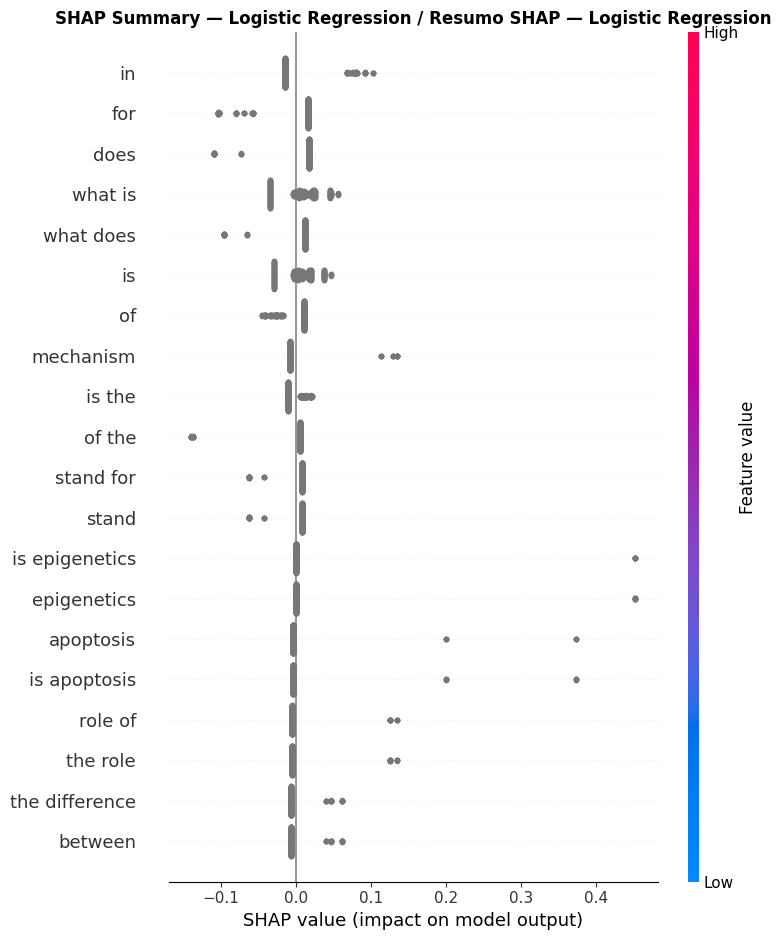

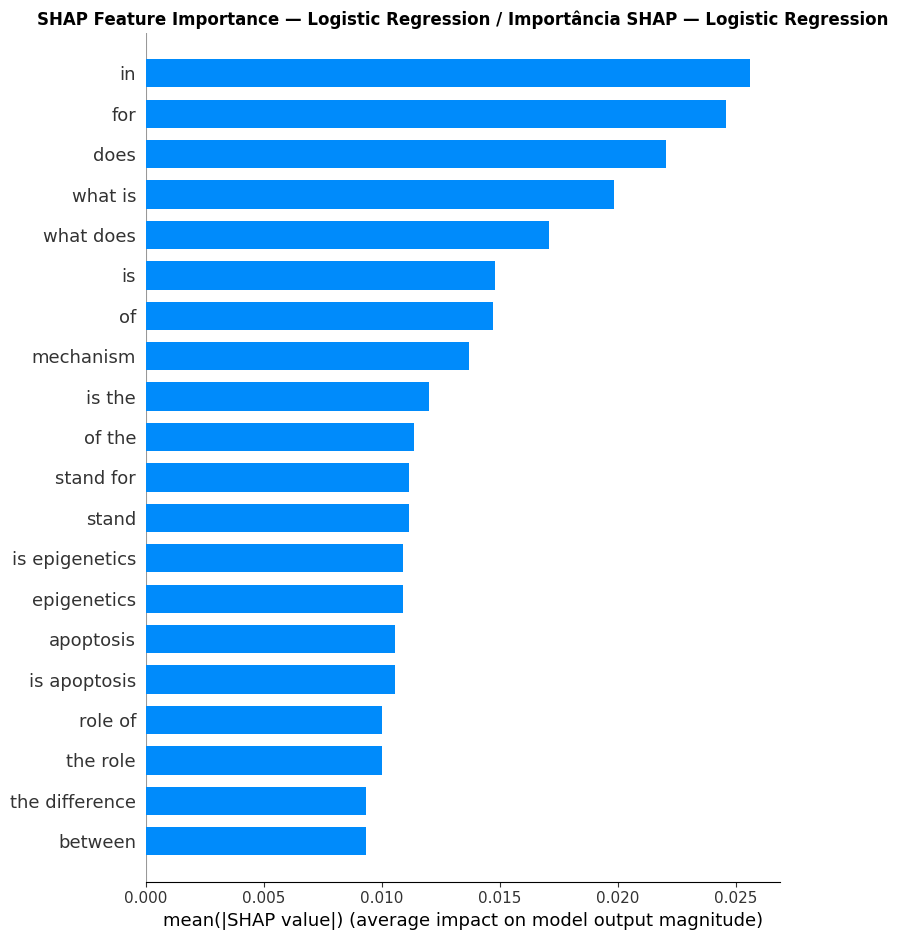

  Done / Concluído: Logistic Regression

Computing SHAP values / Calculando valores SHAP: SGD Classifier


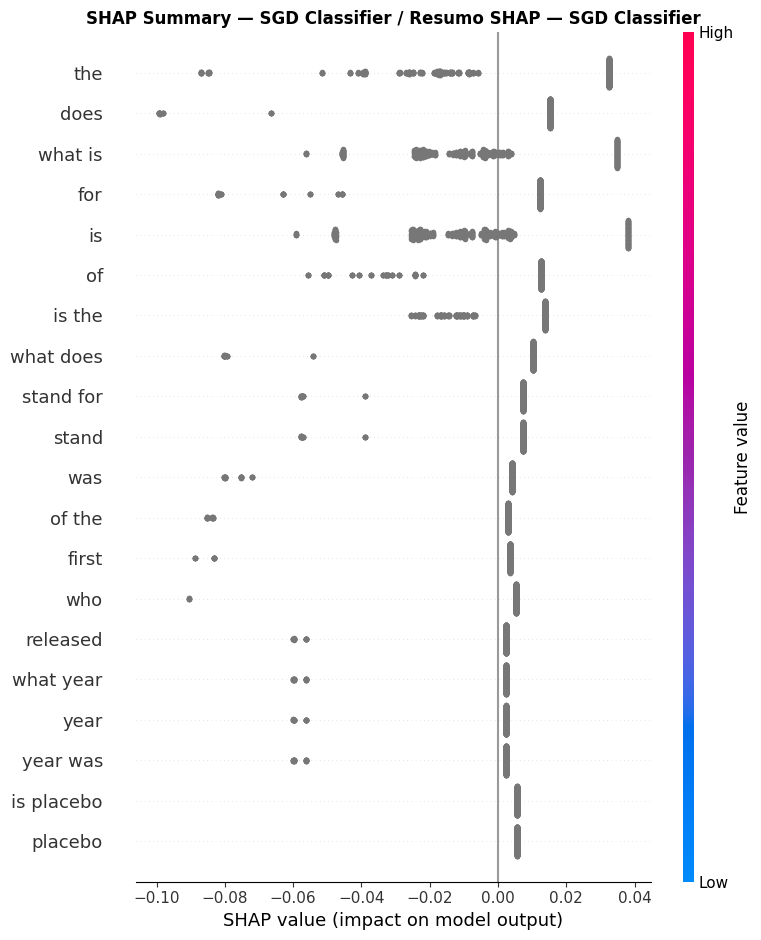

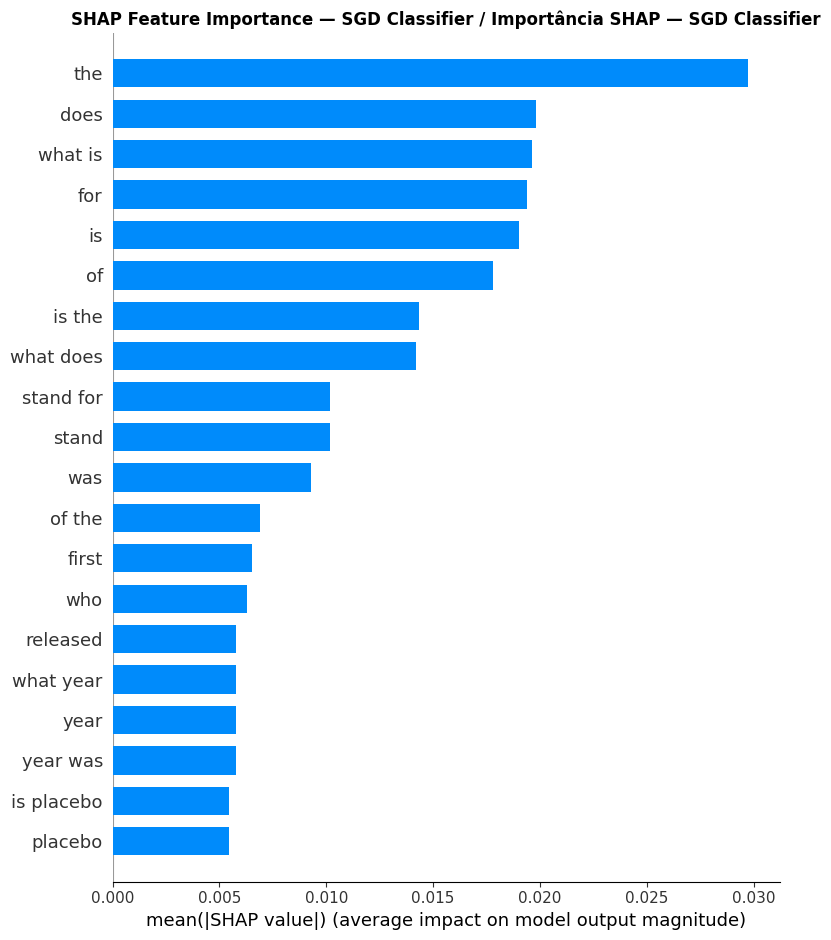

  Done / Concluído: SGD Classifier

Computing SHAP values / Calculando valores SHAP: Linear SVM


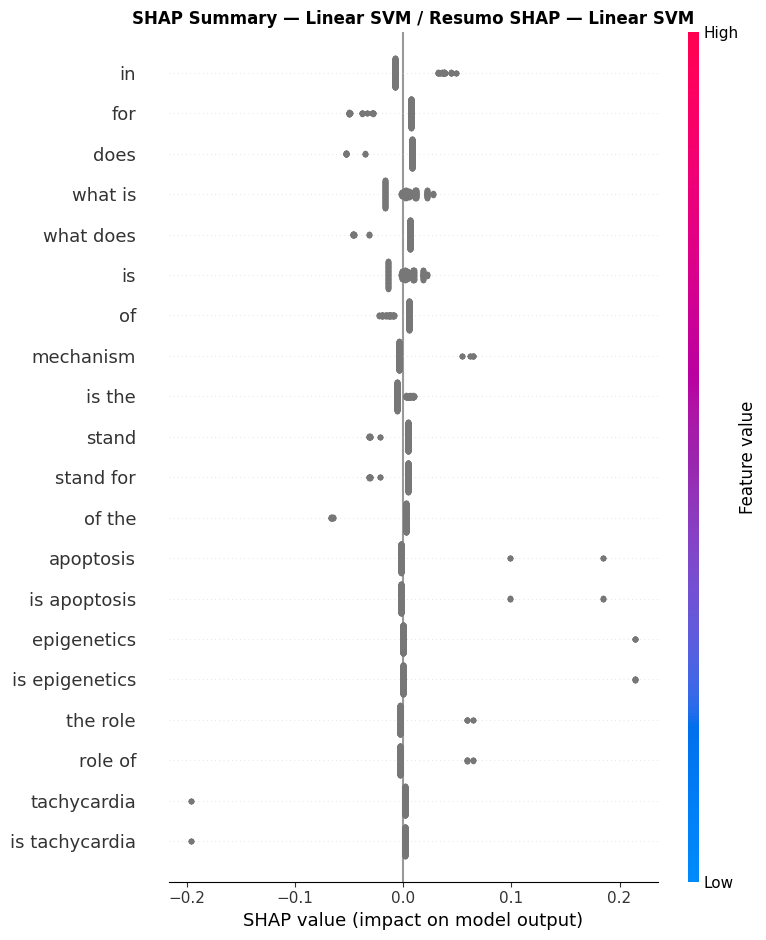

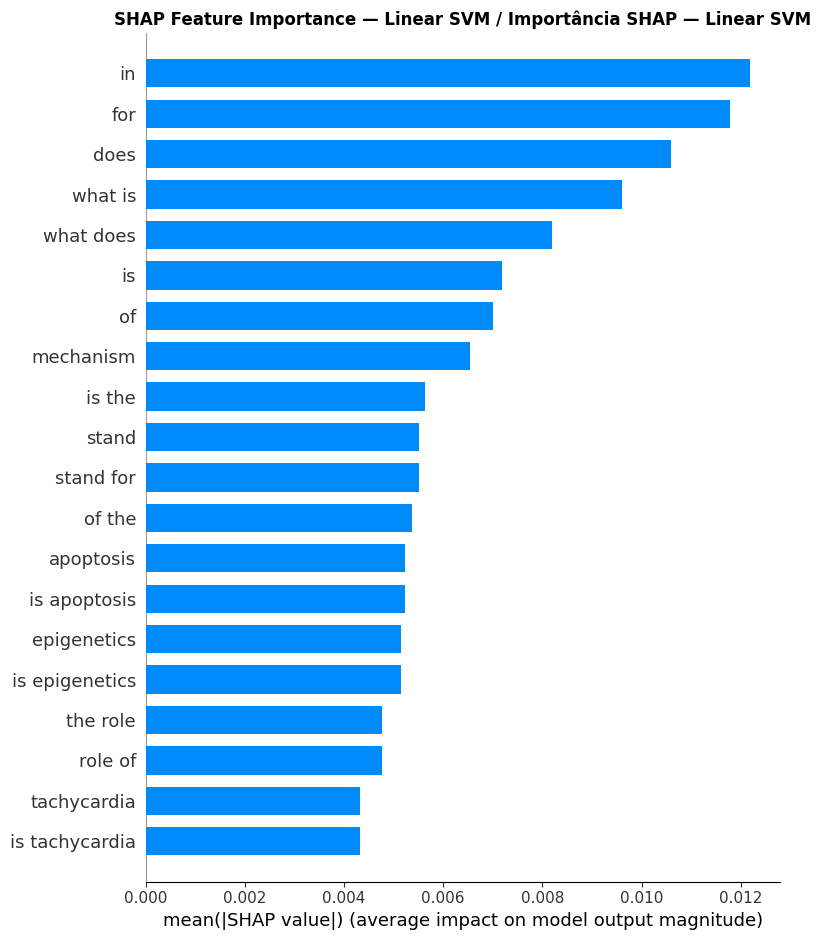

  Done / Concluído: Linear SVM

Computing SHAP values / Calculando valores SHAP: LightGBM


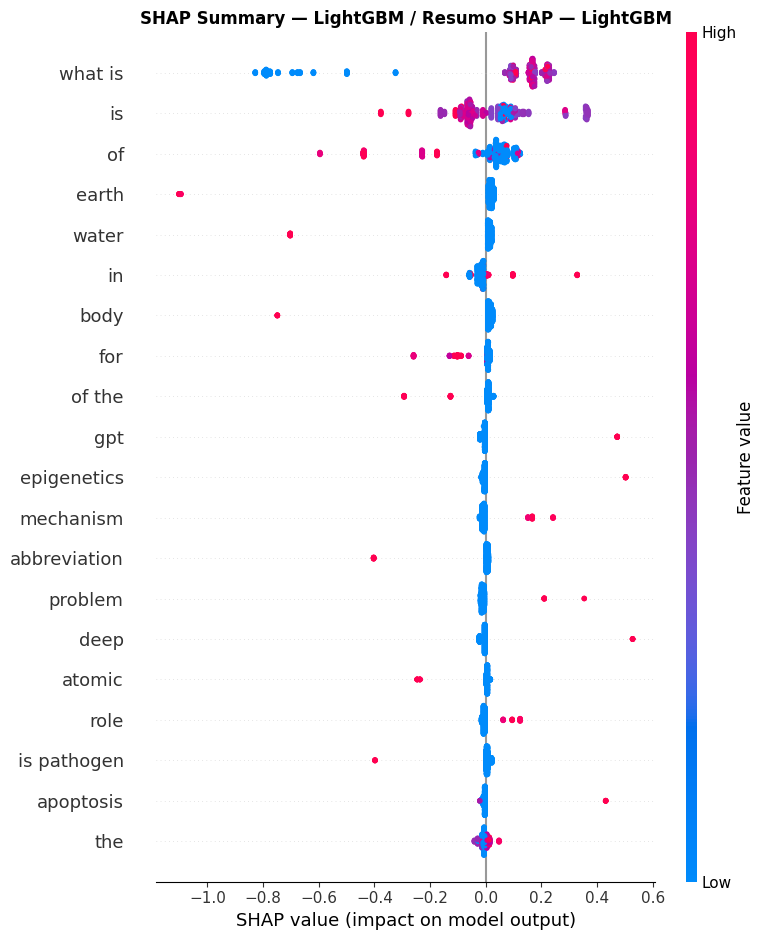

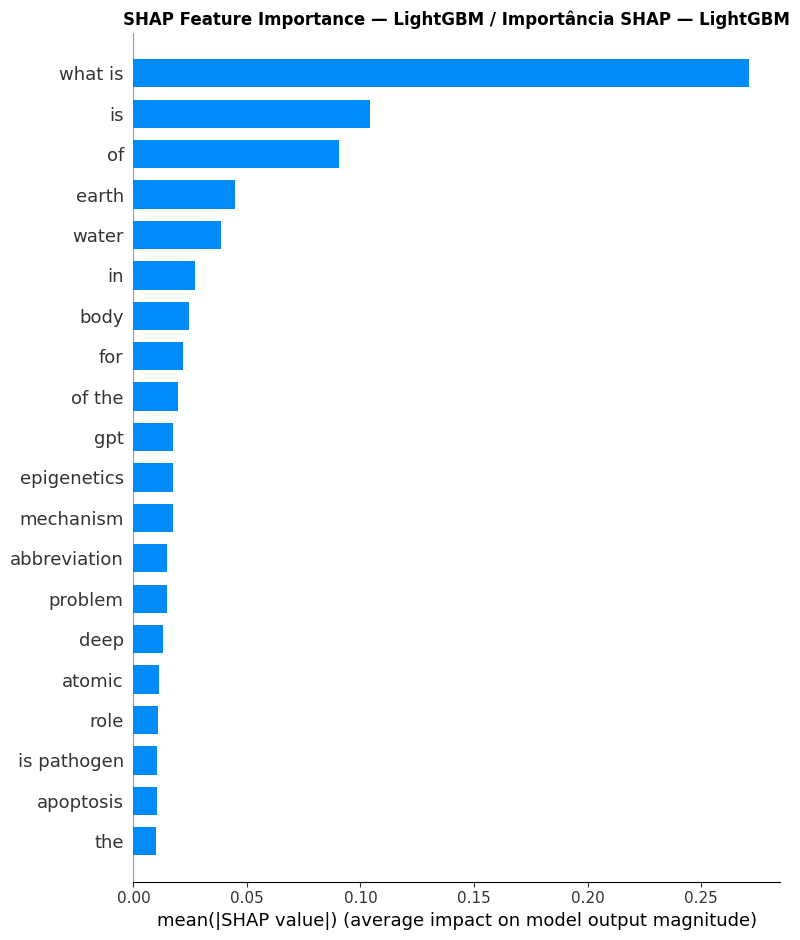

  Done / Concluído: LightGBM

Computing SHAP values / Calculando valores SHAP: Random Forest


ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was 41.374712, while the model output was 0.696969. If this difference is acceptable you can set check_additivity=False to disable this check.

In [35]:
# shap feature importance for all compatible models / importância de features shap para todos os modelos compatíveis
import shap
import matplotlib.pyplot as plt
import numpy as np

shap.initjs()

feature_names = tfidf_exp1.get_feature_names_out()

# convert sparse to dense for tree models / converte esparso para denso para modelos de árvore
X_test_dense  = X_test_tfidf[:500].toarray()
X_train_dense = X_train_tfidf.toarray()

# models compatible with shap / modelos compatíveis com shap
shap_compatible_models = {
    "Logistic Regression": (model_definitions["Logistic Regression"], "linear"),
    "SGD Classifier":      (model_definitions["SGD Classifier"],      "linear"),
    "Linear SVM":          (model_definitions["Linear SVM"],          "linear"),
    "LightGBM":            (model_definitions["LightGBM"],            "tree"),
    "Random Forest":       (model_definitions["Random Forest"],       "tree"),
    "Extra Trees":         (model_definitions["Extra Trees"],         "tree"),
}

shap_results = {}

for name, (model, shap_type) in shap_compatible_models.items():
    print(f"\nComputing SHAP values / Calculando valores SHAP: {name}")

    if shap_type == "linear":
        explainer   = shap.LinearExplainer(model, X_train_tfidf, feature_perturbation="interventional")
        shap_values = explainer.shap_values(X_test_tfidf[:500])
        X_plot      = X_test_tfidf[:500]

    elif shap_type == "tree":
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_dense)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        X_plot      = X_test_dense

    mean_shap = np.abs(shap_values).mean(axis=0)
    shap_results[name] = mean_shap

    # summary plot / gráfico summary
    shap.summary_plot(
        shap_values,
        X_plot,
        feature_names=feature_names,
        max_display=20,
        show=False,
    )
    plt.title(
        f"SHAP Summary — {name} / Resumo SHAP — {name}",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(f"nb3_shap_summary_{name.lower().replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # bar plot / gráfico de barras
    shap.summary_plot(
        shap_values,
        X_plot,
        feature_names=feature_names,
        max_display=20,
        plot_type="bar",
        show=False,
    )
    plt.title(
        f"SHAP Feature Importance — {name} / Importância SHAP — {name}",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(f"nb3_shap_bar_{name.lower().replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"  Done / Concluído: {name}")

In [38]:
# shap comparison dataframe all models / dataframe comparativo shap todos os modelos
df_shap = pd.DataFrame(shap_results, index=feature_names)
df_shap["shap_mean"] = df_shap.mean(axis=1)
df_shap = df_shap.sort_values("shap_mean", ascending=False).reset_index()
df_shap = df_shap.rename(columns={"index": "feature"})

print("\n=== Top 20 SHAP Features — All Models / Top 20 Features SHAP — Todos os Modelos ===")
print(df_shap.head(20).to_string(index=False))


=== Top 20 SHAP Features — All Models / Top 20 Features SHAP — Todos os Modelos ===
       feature  Logistic Regression  SGD Classifier  Linear SVM  LightGBM  shap_mean
       what is             0.019812        0.019644    0.009606  0.271228   0.080073
            is             0.014790        0.019002    0.007194  0.104133   0.036280
            of             0.014686        0.017813    0.007002  0.090674   0.032544
           for             0.024555        0.019378    0.011787  0.021769   0.019372
            in             0.025578        0.000435    0.012183  0.027315   0.016378
          does             0.022013        0.019810    0.010595  0.002822   0.013810
         earth             0.004172        0.002641    0.001927  0.044678   0.013354
           the             0.007448        0.029741    0.003553  0.009981   0.012681
         water             0.003736        0.002205    0.001742  0.038462   0.011536
        of the             0.011361        0.006877    0.005376  

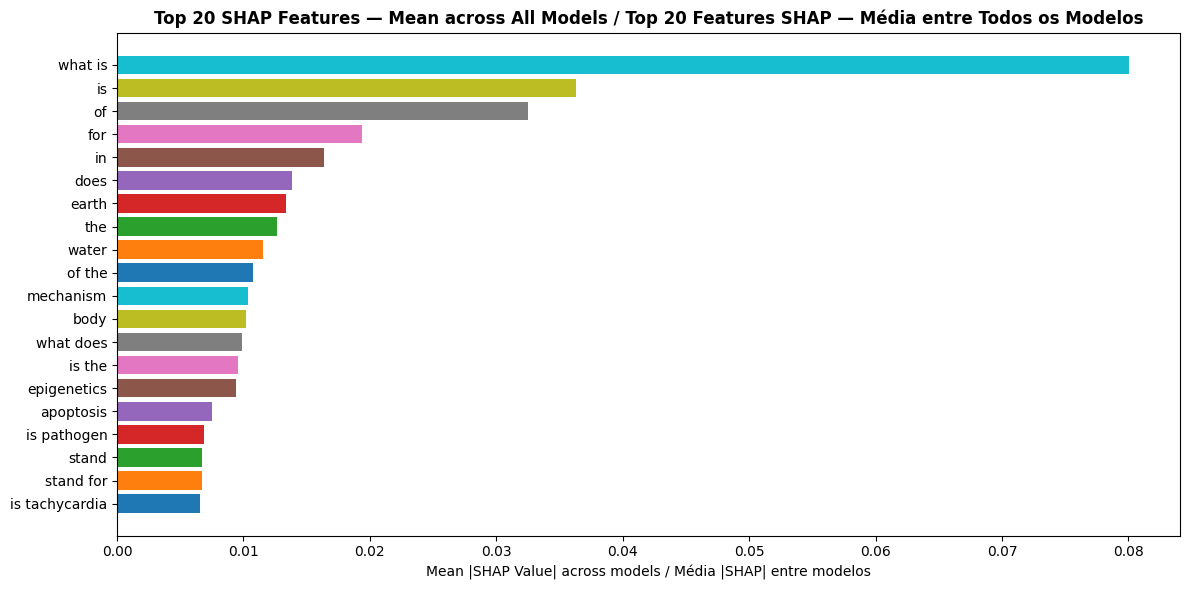


Saved: nb3_shap_features.csv


In [39]:
# top 20 shap mean features bar plot / gráfico top 20 features shap média
fig, ax = plt.subplots(figsize=(12, 6))
top20 = df_shap.head(20)

ax.barh(
    top20["feature"][::-1],
    top20["shap_mean"][::-1],
    color=sns.color_palette("tab10", 20),
)
ax.set_xlabel("Mean |SHAP Value| across models / Média |SHAP| entre modelos")
ax.set_title(
    "Top 20 SHAP Features — Mean across All Models / Top 20 Features SHAP — Média entre Todos os Modelos",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("nb3_shap_top20_mean.png", dpi=150, bbox_inches="tight")
plt.show()


# save shap dataframe / salva dataframe shap
df_shap.to_csv("nb3_shap_features.csv", index=False)
print("\nSaved: nb3_shap_features.csv")

# Part 12 - Metrics and evaluations

In [40]:
# classification report for all models / relatório de classificação para todos os modelos
for name, model in model_definitions.items():
    y_pred = model.predict(X_test_tfidf)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Correct", "Hallucinated"]))


=== Naive Bayes ===
              precision    recall  f1-score   support

     Correct       0.82      0.83      0.83     23686
Hallucinated       0.37      0.35      0.36      6554

    accuracy                           0.73     30240
   macro avg       0.60      0.59      0.59     30240
weighted avg       0.72      0.73      0.73     30240


=== Complement Naive Bayes ===
              precision    recall  f1-score   support

     Correct       0.86      0.53      0.66     23686
Hallucinated       0.29      0.70      0.41      6554

    accuracy                           0.57     30240
   macro avg       0.58      0.62      0.54     30240
weighted avg       0.74      0.57      0.61     30240


=== Logistic Regression ===
              precision    recall  f1-score   support

     Correct       0.86      0.57      0.69     23686
Hallucinated       0.30      0.65      0.41      6554

    accuracy                           0.59     30240
   macro avg       0.58      0.61      0.55   

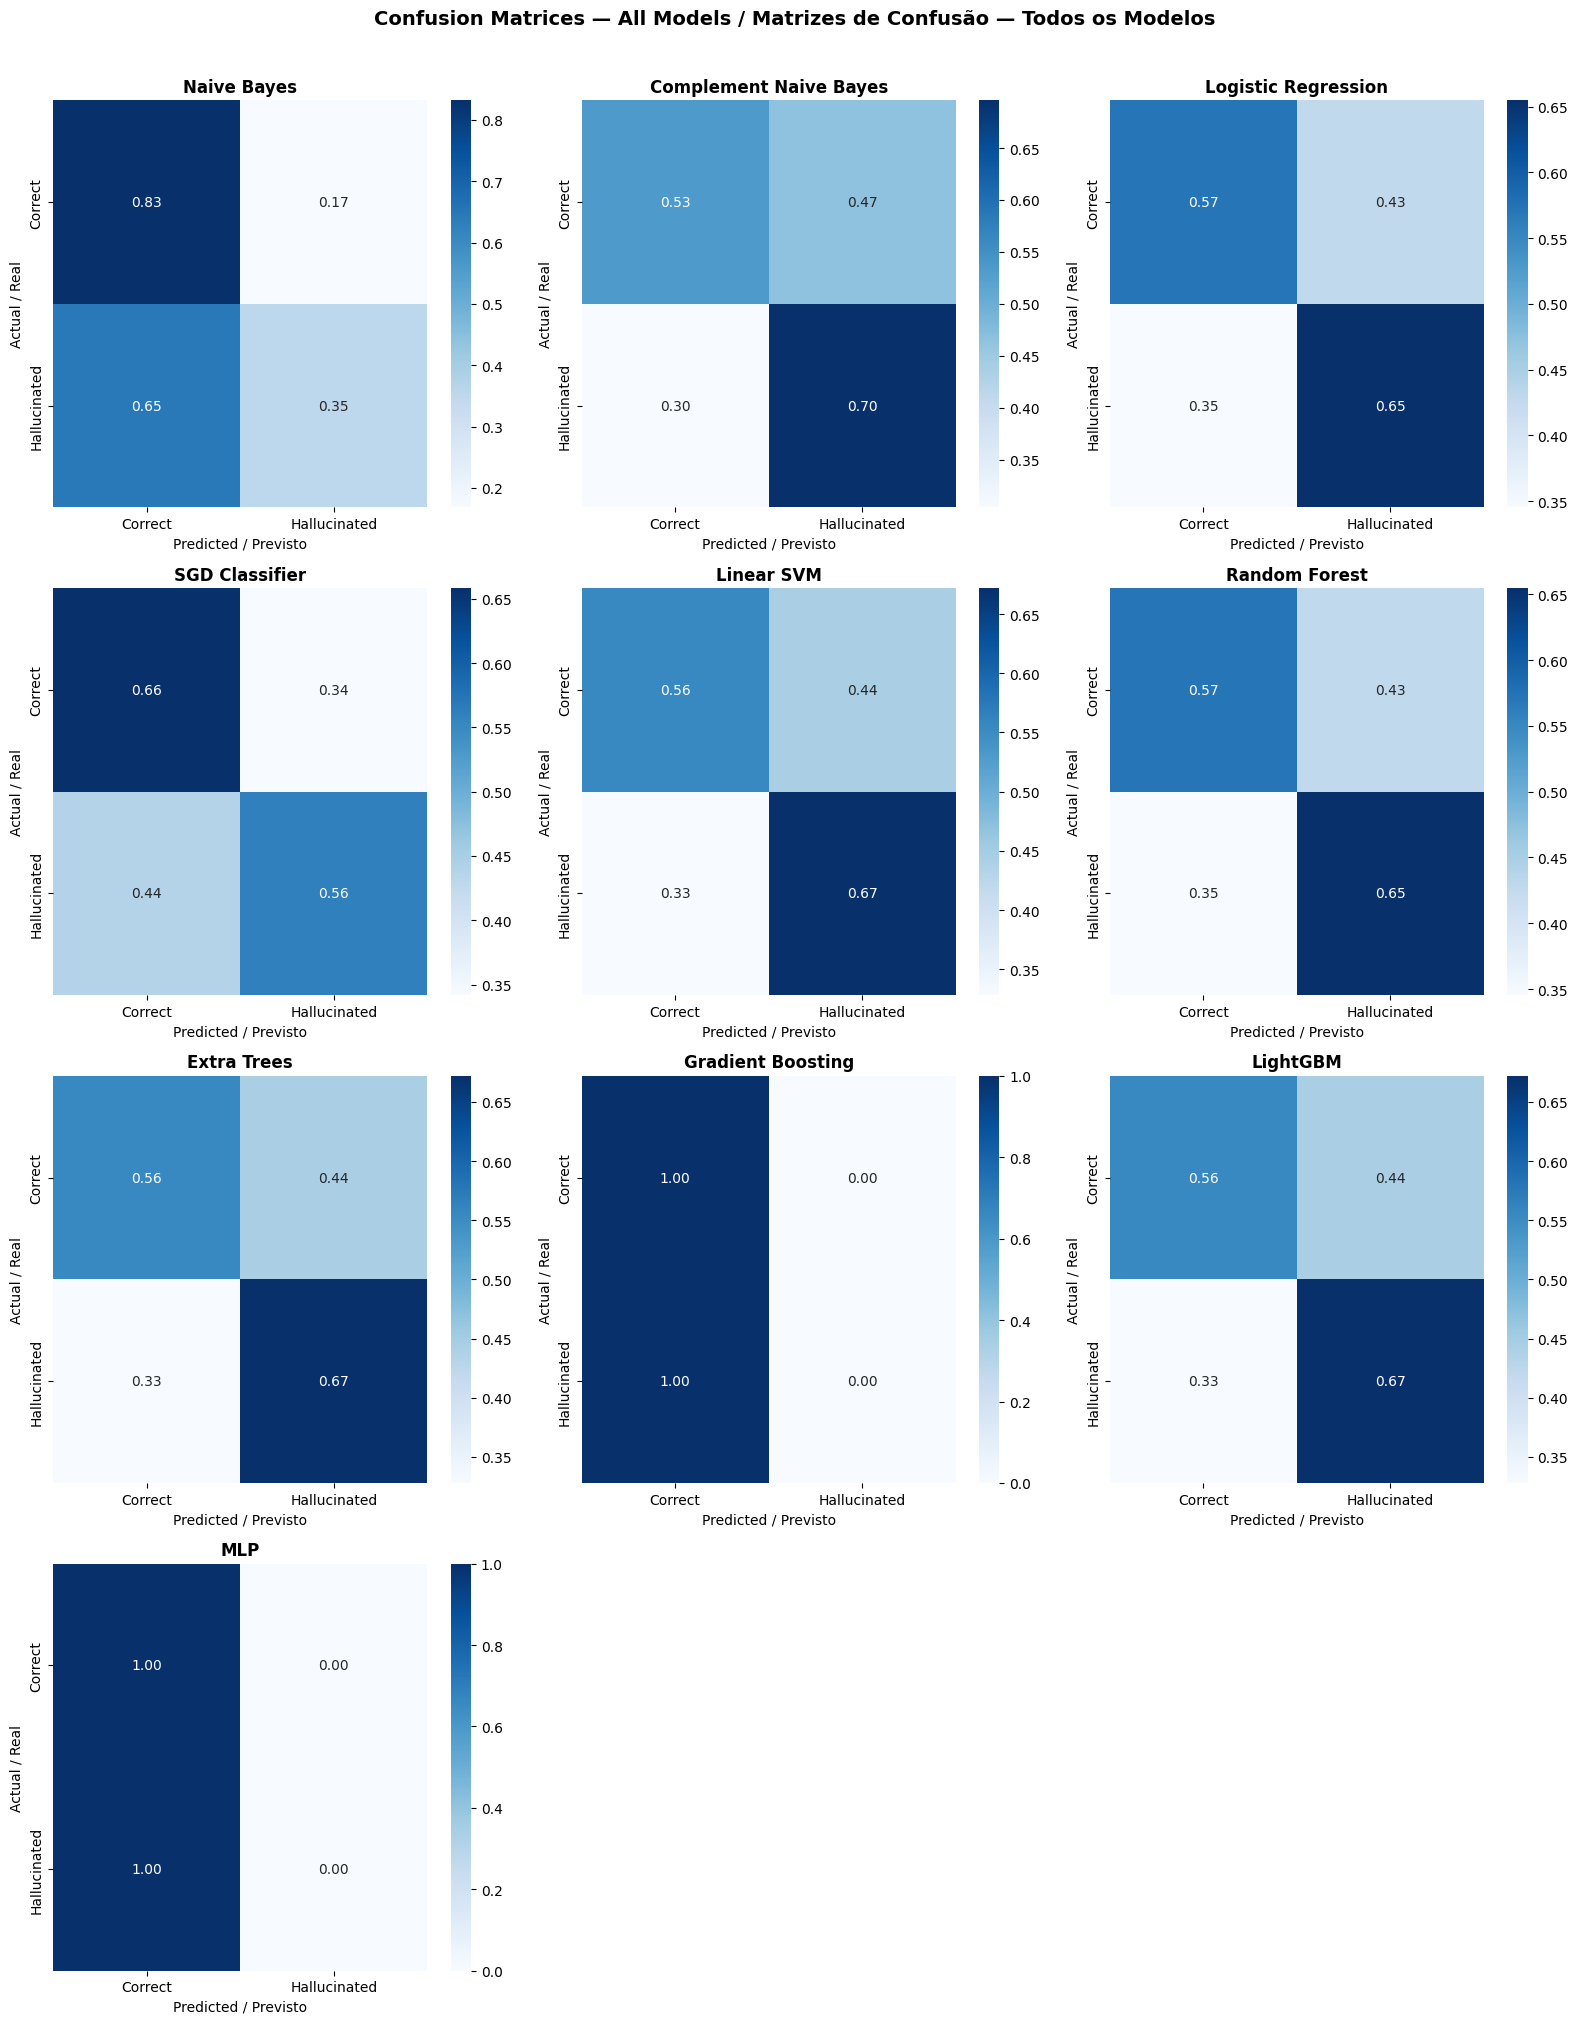

In [41]:
# confusion matrices for all models / matrizes de confusão para todos os modelos
n_models = len(model_definitions)
ncols    = 3
nrows    = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

for i, (name, model) in enumerate(model_definitions.items()):
    y_pred = model.predict(X_test_tfidf)
    cm     = confusion_matrix(y_test, y_pred, normalize="true")
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=["Correct", "Hallucinated"],
        yticklabels=["Correct", "Hallucinated"],
        ax=axes[i],
    )
    axes[i].set_title(name, fontweight="bold")
    axes[i].set_xlabel("Predicted / Previsto")
    axes[i].set_ylabel("Actual / Real")

# hide unused axes / esconde eixos não utilizados
for i in range(n_models, len(axes)):
    axes[i].axis("off")

plt.suptitle(
    "Confusion Matrices — All Models / Matrizes de Confusão — Todos os Modelos",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig("nb3_exp1_all_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

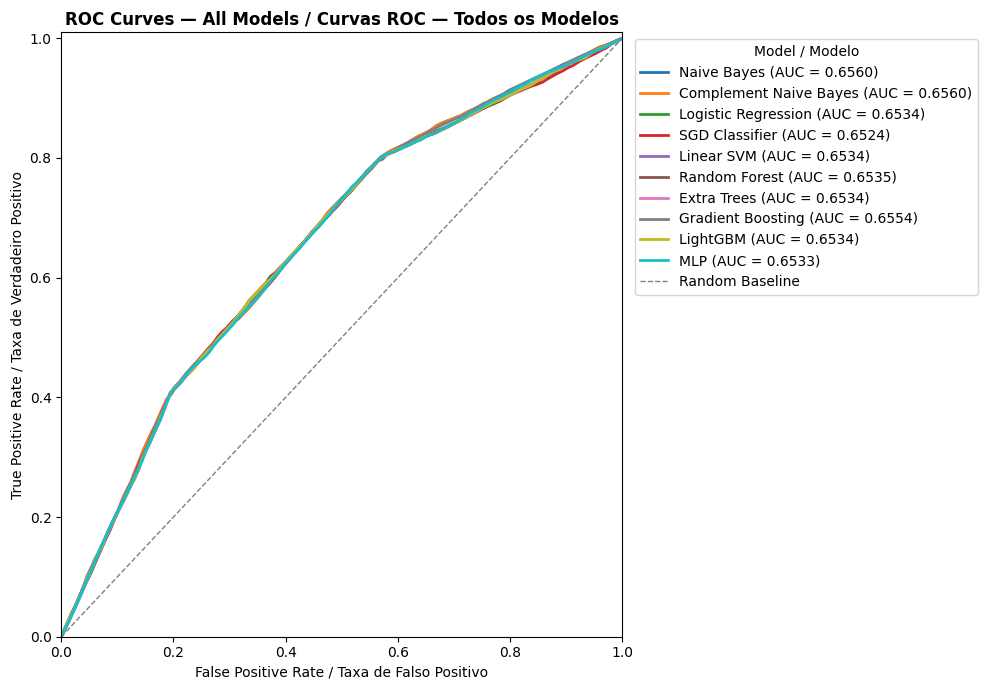

In [42]:
# roc curves for all models / curvas roc para todos os modelos
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 7))
colors  = sns.color_palette("tab10", len(model_definitions))

for (name, model), color in zip(model_definitions.items(), colors):
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_score = model.decision_function(X_test_tfidf)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

# random baseline / linha de base aleatória
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random Baseline")

ax.set_xlabel("False Positive Rate / Taxa de Falso Positivo")
ax.set_ylabel("True Positive Rate / Taxa de Verdadeiro Positivo")
ax.set_title(
    "ROC Curves — All Models / Curvas ROC — Todos os Modelos",
    fontweight="bold",
)
ax.legend(title="Model / Modelo", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.savefig("nb3_exp1_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [48]:
# metrics dataframe with accuracy and f1 score / dataframe de métricas com acurácia e f1 score
from sklearn.metrics import accuracy_score

metrics_rows = []

for name, model in model_definitions.items():
    y_pred  = model.predict(X_test_tfidf)
    report  = classification_report(y_test, y_pred, output_dict=True)

    metrics_rows.append({
        "model":              name,
        "accuracy":           round(accuracy_score(y_test, y_pred), 4),
        "f1_class0":          round(report["0"]["f1-score"], 4),
        "f1_class1":          round(report["1"]["f1-score"], 4),
        "precision_class1":   round(report["1"]["precision"], 4),
        "recall_class1":      round(report["1"]["recall"], 4),
        "macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "weighted_f1":        round(report["weighted avg"]["f1-score"], 4),
    })

df_metrics = pd.DataFrame(metrics_rows).sort_values("f1_class1", ascending=False).reset_index(drop=True)

print("=== Metrics Summary / Resumo de Métricas ===")
print(df_metrics.to_string(index=False))


# save metrics dataframe / salva dataframe de métricas
df_metrics.to_csv("nb3_exp1_metrics.csv", index=False)
print("\nSaved: nb3_exp1_metrics.csv")

=== Metrics Summary / Resumo de Métricas ===
                 model  accuracy  f1_class0  f1_class1  precision_class1  recall_class1  macro_f1  weighted_f1
Complement Naive Bayes    0.5696     0.6606     0.4121            0.2927         0.6959    0.5363       0.6067
            Linear SVM    0.5813     0.6754     0.4102            0.2953         0.6720    0.5428       0.6179
              LightGBM    0.5813     0.6754     0.4102            0.2953         0.6720    0.5428       0.6179
           Extra Trees    0.5813     0.6754     0.4102            0.2953         0.6720    0.5428       0.6179
         Random Forest    0.5899     0.6860     0.4090            0.2974         0.6547    0.5475       0.6260
   Logistic Regression    0.5899     0.6860     0.4090            0.2974         0.6547    0.5475       0.6260
        SGD Classifier    0.6372     0.7397     0.4013            0.3124         0.5610    0.5705       0.6664
           Naive Bayes    0.7284     0.8276     0.3611            0

# Part 13 - Saving ML templates

In [45]:
# save all models / salva todos os modelos
import pickle
import os

os.makedirs("models/exp1", exist_ok=True)

for name, model in model_definitions.items():
    fname = name.lower().replace(" ", "_")
    fpath = f"models/exp1/{fname}.pkl"
    with open(fpath, "wb") as f:
        pickle.dump(model, f)
    print(f"Saved: {fpath}")


# save tfidf vectorizer / salva vetorizador tfidf
with open("models/exp1/tfidf_exp1.pkl", "wb") as f:
    pickle.dump(tfidf_exp1, f)
print("Saved: models/exp1/tfidf_exp1.pkl")


# save metrics dataframe / salva dataframe de métricas
df_metrics.to_csv("models/exp1/metrics_exp1.csv", index=False)
print("Saved: models/exp1/metrics_exp1.csv")


# summary of saved files / resumo dos arquivos salvos
print("\n=== Saved Files / Arquivos Salvos ===")
for fname in os.listdir("models/exp1"):
    fpath    = os.path.join("models/exp1", fname)
    size_kb  = os.path.getsize(fpath) / 1024
    print(f"  {fname}: {size_kb:.1f} KB")

Saved: models/exp1/naive_bayes.pkl
Saved: models/exp1/complement_naive_bayes.pkl
Saved: models/exp1/logistic_regression.pkl
Saved: models/exp1/sgd_classifier.pkl
Saved: models/exp1/linear_svm.pkl
Saved: models/exp1/random_forest.pkl
Saved: models/exp1/extra_trees.pkl
Saved: models/exp1/gradient_boosting.pkl
Saved: models/exp1/lightgbm.pkl
Saved: models/exp1/mlp.pkl
Saved: models/exp1/tfidf_exp1.pkl
Saved: models/exp1/metrics_exp1.csv

=== Saved Files / Arquivos Salvos ===
  naive_bayes.pkl: 22.2 KB
  linear_svm.pkl: 6.0 KB
  tfidf_exp1.pkl: 27.5 KB
  gradient_boosting.pkl: 178.6 KB
  complement_naive_bayes.pkl: 27.7 KB
  random_forest.pkl: 3795.8 KB
  extra_trees.pkl: 3788.9 KB
  lightgbm.pkl: 1515.5 KB
  logistic_regression.pkl: 6.1 KB
  metrics_exp1.csv: 0.4 KB
  sgd_classifier.pkl: 6.4 KB
  mlp.pkl: 6584.0 KB


# Part 14 - Result Final

In [49]:
# best model highlight / destaque do melhor modelo
from IPython.display import display

df_metrics = pd.DataFrame(metrics_rows).sort_values("f1_class1", ascending=False).reset_index(drop=True)

print("Columns / Colunas:", df_metrics.columns.tolist())
print(df_metrics)

Columns / Colunas: ['model', 'accuracy', 'f1_class0', 'f1_class1', 'precision_class1', 'recall_class1', 'macro_f1', 'weighted_f1']
                    model  accuracy  f1_class0  f1_class1  precision_class1  \
0  Complement Naive Bayes    0.5696     0.6606     0.4121            0.2927   
1              Linear SVM    0.5813     0.6754     0.4102            0.2953   
2                LightGBM    0.5813     0.6754     0.4102            0.2953   
3             Extra Trees    0.5813     0.6754     0.4102            0.2953   
4           Random Forest    0.5899     0.6860     0.4090            0.2974   
5     Logistic Regression    0.5899     0.6860     0.4090            0.2974   
6          SGD Classifier    0.6372     0.7397     0.4013            0.3124   
7             Naive Bayes    0.7284     0.8276     0.3611            0.3684   
8       Gradient Boosting    0.7833     0.8785     0.0000            0.0000   
9                     MLP    0.7833     0.8785     0.0000            0.0000   


In [52]:
# highlight best value per metric / destaca melhor valor por métrica
numeric_cols = [c for c in df_metrics.columns if c != "model"]


def highlight_max(s):
    """
    Highlight the maximum value in a Series with green background.

    Destaca o valor máximo em uma Series com fundo verde.
    """
    return ["background-color: #2ca02c; color: white" if v == s.max() else "" for v in s]


styled = (
    df_metrics
    .style
    .apply(highlight_max, subset=numeric_cols)
    .format({col: "{:.4f}" for col in numeric_cols})
    .set_caption("Best Model per Metric / Melhor Modelo por Métrica")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "14px"), ("font-weight", "bold"), ("text-align", "center")],
    }])
)

display(styled)

,model,accuracy,f1_class0,f1_class1,precision_class1,recall_class1,macro_f1,weighted_f1
0,Complement Naive Bayes,0.5696,0.6606,0.4121,0.2927,0.6959,0.5363,0.6067
1,Linear SVM,0.5813,0.6754,0.4102,0.2953,0.6720,0.5428,0.6179
2,LightGBM,0.5813,0.6754,0.4102,0.2953,0.6720,0.5428,0.6179
3,Extra Trees,0.5813,0.6754,0.4102,0.2953,0.6720,0.5428,0.6179
4,Random Forest,0.5899,0.6860,0.4090,0.2974,0.6547,0.5475,0.6260
5,Logistic Regression,0.5899,0.6860,0.4090,0.2974,0.6547,0.5475,0.6260
6,SGD Classifier,0.6372,0.7397,0.4013,0.3124,0.5610,0.5705,0.6664
7,Naive Bayes,0.7284,0.8276,0.3611,0.3684,0.3541,0.5944,0.7265
8,Gradient Boosting,0.7833,0.8785,0.0000,0.0000,0.0000,0.4392,0.6881
9,MLP,0.7833,0.8785,0.0000,0.0000,0.0000,0.4392,0.6881


In [53]:
# best model overall / melhor modelo geral
best_model_name = df_metrics.iloc[0]["model"]

print(f"\nBest Model / Melhor Modelo: {best_model_name}")
for col in numeric_cols:
    print(f"  {col}: {df_metrics.iloc[0][col]:.4f}")


Best Model / Melhor Modelo: Complement Naive Bayes
  accuracy: 0.5696
  f1_class0: 0.6606
  f1_class1: 0.4121
  precision_class1: 0.2927
  recall_class1: 0.6959
  macro_f1: 0.5363
  weighted_f1: 0.6067


# Part 15 - Experiment 2 — Prompt Text + Metadata ML

In [54]:
# experiment 2 — prompt text + metadata / experimento 2 — texto do prompt + metadados
from IPython.display import display, Markdown
import scipy.sparse as sp

display(Markdown("""
## Experiment 2 — Prompt Text + Metadata
## Experimento 2 — Texto do Prompt + Metadados

**Features:** `prompt_text` + `model_name` + `topic_category` + `difficulty` + `prompt_source`  
**Target:** `hallucinated`  
**Goal / Objetivo:** Verificar se adicionar metadados ao texto do prompt melhora a detecção de alucinação.
"""))


# tfidf on prompt text / tfidf no texto do prompt
tfidf_exp2 = TfidfVectorizer(
    max_features=20000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

X_train_tfidf2 = tfidf_exp2.fit_transform(df_train["prompt_text"])
X_test_tfidf2  = tfidf_exp2.transform(df_test["prompt_text"])

print(f"TF-IDF shape train / Shape treino: {X_train_tfidf2.shape}")
print(f"TF-IDF shape test / Shape teste:  {X_test_tfidf2.shape}")


## Experiment 2 — Prompt Text + Metadata
## Experimento 2 — Texto do Prompt + Metadados

**Features:** `prompt_text` + `model_name` + `topic_category` + `difficulty` + `prompt_source`  
**Target:** `hallucinated`  
**Goal / Objetivo:** Verificar se adicionar metadados ao texto do prompt melhora a detecção de alucinação.


TF-IDF shape train / Shape treino: (120960, 692)
TF-IDF shape test / Shape teste:  (30240, 692)


In [55]:
# metadata features / features de metadados
meta_cols = ["model_name_enc", "topic_category_enc", "difficulty_enc", "prompt_source_enc"]

X_train_meta = sp.csr_matrix(df_train[meta_cols].values)
X_test_meta  = sp.csr_matrix(df_test[meta_cols].values)

print(f"\nMetadata shape train / Shape metadados treino: {X_train_meta.shape}")
print(f"Metadata shape test / Shape metadados teste:  {X_test_meta.shape}")


Metadata shape train / Shape metadados treino: (120960, 4)
Metadata shape test / Shape metadados teste:  (30240, 4)


In [56]:
# combine tfidf and metadata / combina tfidf e metadados
X_train_exp2 = sp.hstack([X_train_tfidf2, X_train_meta])
X_test_exp2  = sp.hstack([X_test_tfidf2,  X_test_meta])

print(f"\nCombined shape train / Shape combinado treino: {X_train_exp2.shape}")
print(f"Combined shape test / Shape combinado teste:  {X_test_exp2.shape}")


Combined shape train / Shape combinado treino: (120960, 696)
Combined shape test / Shape combinado teste:  (30240, 696)


In [57]:
# model definitions experiment 2 / definição dos modelos experimento 2
model_definitions_exp2 = {"Naive Bayes": MultinomialNB(alpha=0.1),
                          "Complement Naive Bayes": ComplementNB(alpha=0.1),
                          "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42, n_jobs=-1),
                          "SGD Classifier": SGDClassifier(loss="modified_huber", class_weight="balanced", random_state=42, n_jobs=-1),
                          "Linear SVM": LinearSVC(class_weight="balanced", random_state=42, max_iter=2000),
                          "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
                          "Extra Trees": ExtraTreesClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
                          "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
                          "LightGBM": LGBMClassifier(n_estimators=400, learning_rate=0.05, class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1),
                         }


# train and evaluate all models / treina e avalia todos os modelos
metrics_rows_exp2 = []

for name, model in model_definitions_exp2.items():
    print(f"\nTraining / Treinando: {name}")
    start = time.time()

    model.fit(X_train_exp2, y_train)
    elapsed = time.time() - start

    y_pred  = model.predict(X_test_exp2)
    report  = classification_report(y_test, y_pred, output_dict=True)

    metrics_rows_exp2.append({
        "model":            name,
        "accuracy":         round(accuracy_score(y_test, y_pred), 4),
        "f1_class0":        round(report["0"]["f1-score"], 4),
        "f1_class1":        round(report["1"]["f1-score"], 4),
        "precision_class1": round(report["1"]["precision"], 4),
        "recall_class1":    round(report["1"]["recall"], 4),
        "macro_f1":         round(report["macro avg"]["f1-score"], 4),
        "weighted_f1":      round(report["weighted avg"]["f1-score"], 4),
        "train_time_sec":   round(elapsed, 2),
    })

    print(f"  F1 class 1: {metrics_rows_exp2[-1]['f1_class1']}  |  Accuracy: {metrics_rows_exp2[-1]['accuracy']}  |  Time: {elapsed:.2f}s")


Training / Treinando: Naive Bayes
  F1 class 1: 0.3651  |  Accuracy: 0.7277  |  Time: 0.03s

Training / Treinando: Complement Naive Bayes
  F1 class 1: 0.4157  |  Accuracy: 0.5399  |  Time: 0.02s

Training / Treinando: Logistic Regression
  F1 class 1: 0.4147  |  Accuracy: 0.6174  |  Time: 3.64s

Training / Treinando: SGD Classifier
  F1 class 1: 0.4066  |  Accuracy: 0.6479  |  Time: 3.16s

Training / Treinando: Linear SVM
  F1 class 1: 0.4145  |  Accuracy: 0.617  |  Time: 0.69s

Training / Treinando: Random Forest
  F1 class 1: 0.4062  |  Accuracy: 0.6292  |  Time: 236.17s

Training / Treinando: Extra Trees
  F1 class 1: 0.4085  |  Accuracy: 0.6123  |  Time: 131.91s

Training / Treinando: Gradient Boosting
  F1 class 1: 0.0046  |  Accuracy: 0.7834  |  Time: 33.36s

Training / Treinando: LightGBM
  F1 class 1: 0.427  |  Accuracy: 0.6338  |  Time: 2.49s

Training / Treinando: MLP
  F1 class 1: 0.118  |  Accuracy: 0.7795  |  Time: 1711.87s


In [58]:
# results dataframe / dataframe de resultados
df_metrics_exp2 = pd.DataFrame(metrics_rows_exp2).sort_values("f1_class1", ascending=False).reset_index(drop=True)

numeric_cols_exp2 = [c for c in df_metrics_exp2.columns if c != "model"]


def highlight_max(s):
    """
    Highlight the maximum value in a Series with green background.

    Destaca o valor máximo em uma Series com fundo verde.
    """
    return ["background-color: #2ca02c; color: white" if v == s.max() else "" for v in s]


styled_exp2 = (
    df_metrics_exp2
    .style
    .apply(highlight_max, subset=numeric_cols_exp2)
    .format({col: "{:.4f}" for col in numeric_cols_exp2})
    .set_caption("Experiment 2 — Best Model per Metric / Experimento 2 — Melhor Modelo por Métrica")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "14px"), ("font-weight", "bold"), ("text-align", "center")],
    }])
)

display(styled_exp2)

,model,accuracy,f1_class0,f1_class1,precision_class1,recall_class1,macro_f1,weighted_f1,train_time_sec
0,LightGBM,0.6338,0.7309,0.4270,0.3230,0.6295,0.5789,0.6650,2.4900
1,Complement Naive Bayes,0.5399,0.6205,0.4157,0.2868,0.7551,0.5181,0.5761,0.0200
2,Logistic Regression,0.6174,0.7158,0.4147,0.3102,0.6253,0.5652,0.6505,3.6400
3,Linear SVM,0.6170,0.7154,0.4145,0.3099,0.6256,0.5650,0.6502,0.6900
4,Extra Trees,0.6123,0.7117,0.4085,0.3052,0.6176,0.5601,0.6460,131.9100
5,SGD Classifier,0.6479,0.7496,0.4066,0.3203,0.5568,0.5781,0.6753,3.1600
6,Random Forest,0.6292,0.7304,0.4062,0.3111,0.5853,0.5683,0.6601,236.1700
7,Naive Bayes,0.7277,0.8267,0.3651,0.3690,0.3612,0.5959,0.7266,0.0300
8,MLP,0.7795,0.8740,0.1180,0.4433,0.0681,0.4960,0.7101,1711.8700
9,Gradient Boosting,0.7834,0.8785,0.0046,0.5556,0.0023,0.4415,0.6891,33.3600


In [59]:
# classification report for all models / relatório de classificação para todos os modelos
for name, model in model_definitions_exp2.items():
    y_pred = model.predict(X_test_exp2)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Correct", "Hallucinated"]))


=== Naive Bayes ===
              precision    recall  f1-score   support

     Correct       0.82      0.83      0.83     23686
Hallucinated       0.37      0.36      0.37      6554

    accuracy                           0.73     30240
   macro avg       0.60      0.60      0.60     30240
weighted avg       0.73      0.73      0.73     30240


=== Complement Naive Bayes ===
              precision    recall  f1-score   support

     Correct       0.88      0.48      0.62     23686
Hallucinated       0.29      0.76      0.42      6554

    accuracy                           0.54     30240
   macro avg       0.58      0.62      0.52     30240
weighted avg       0.75      0.54      0.58     30240


=== Logistic Regression ===
              precision    recall  f1-score   support

     Correct       0.86      0.62      0.72     23686
Hallucinated       0.31      0.63      0.41      6554

    accuracy                           0.62     30240
   macro avg       0.58      0.62      0.57   

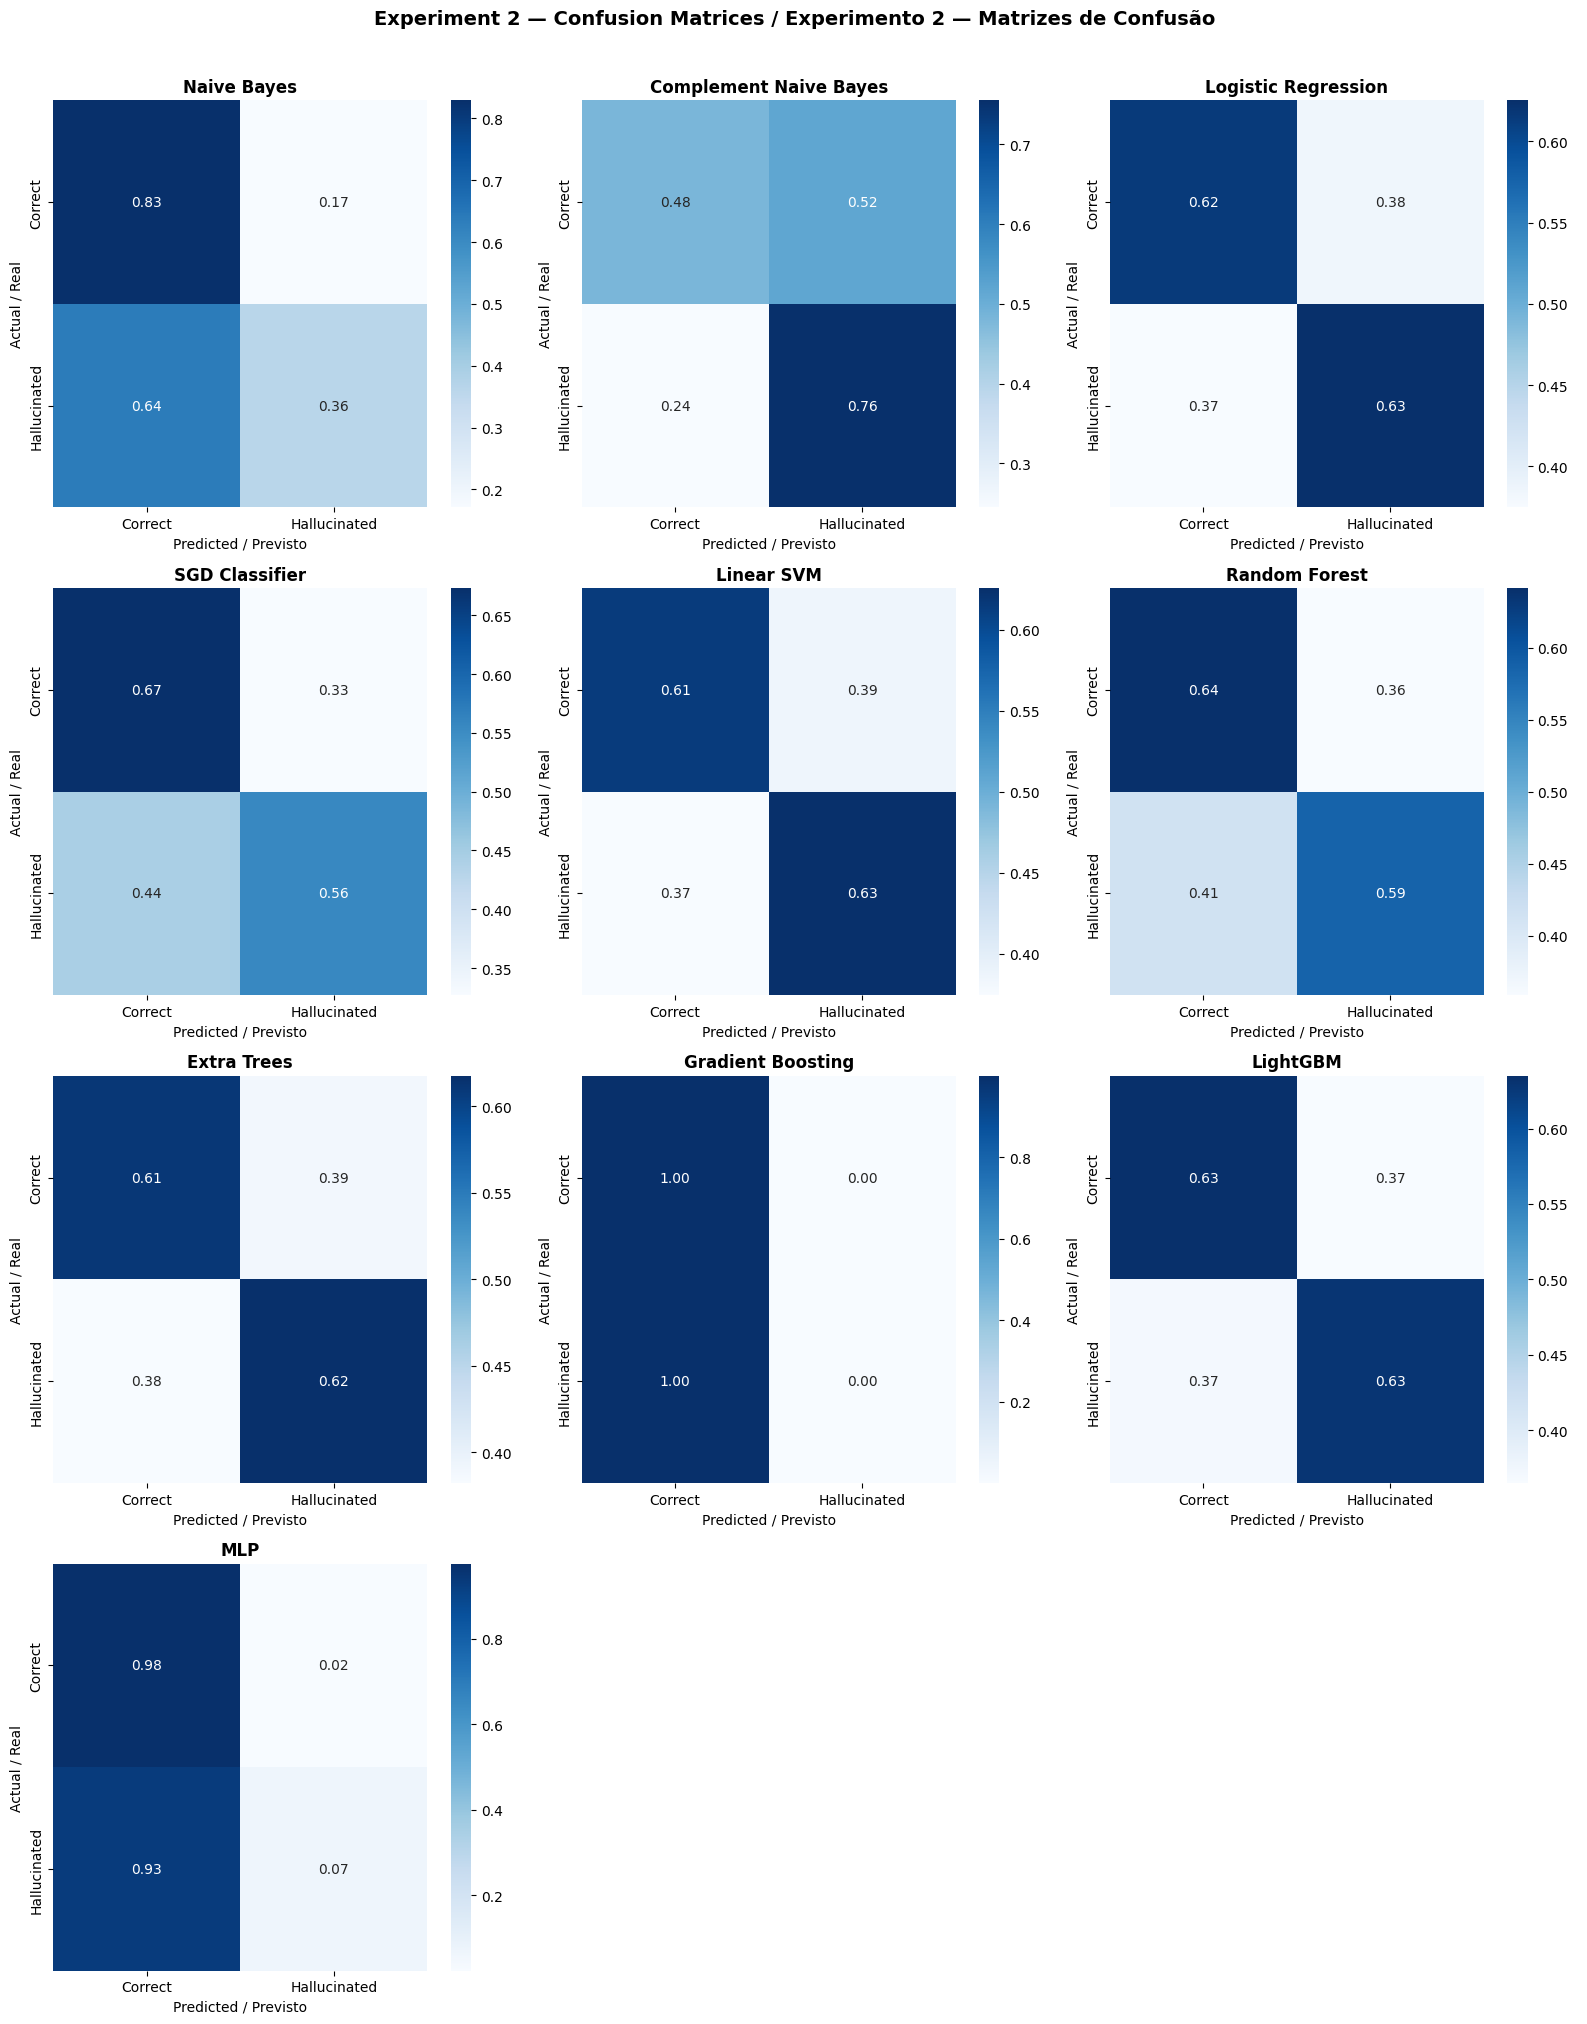

In [60]:
# confusion matrices for all models / matrizes de confusão para todos os modelos
n_models = len(model_definitions_exp2)
ncols    = 3
nrows    = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

for i, (name, model) in enumerate(model_definitions_exp2.items()):
    y_pred = model.predict(X_test_exp2)
    cm     = confusion_matrix(y_test, y_pred, normalize="true")
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=["Correct", "Hallucinated"],
        yticklabels=["Correct", "Hallucinated"],
        ax=axes[i],
    )
    axes[i].set_title(name, fontweight="bold")
    axes[i].set_xlabel("Predicted / Previsto")
    axes[i].set_ylabel("Actual / Real")

for i in range(n_models, len(axes)):
    axes[i].axis("off")

plt.suptitle(
    "Experiment 2 — Confusion Matrices / Experimento 2 — Matrizes de Confusão",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("nb3_exp2_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

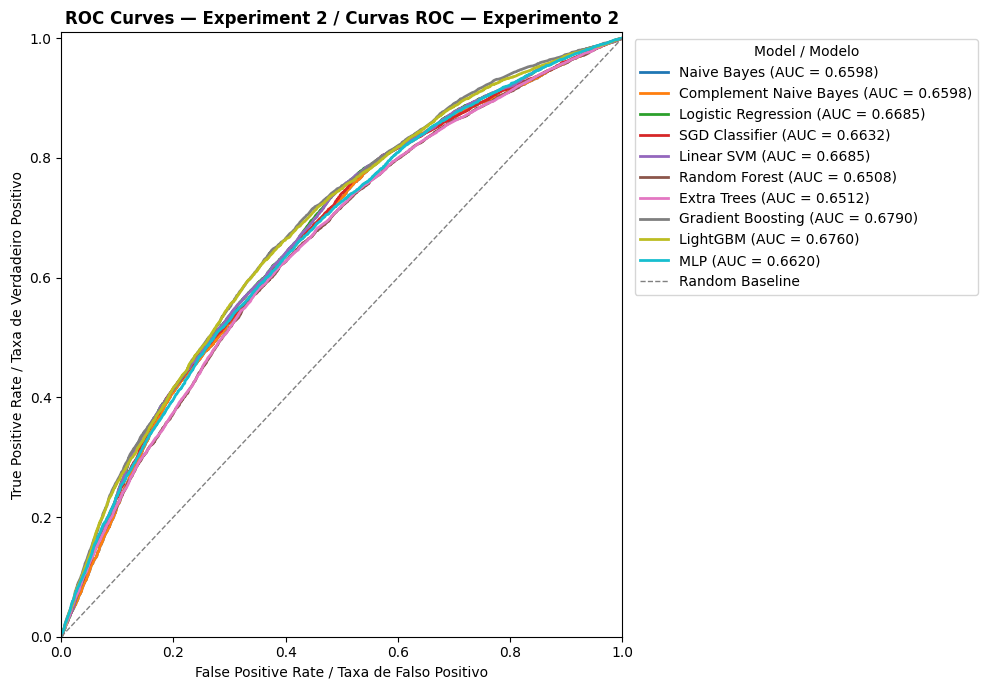

In [61]:
# roc curves for all models / curvas roc para todos os modelos
fig, ax = plt.subplots(figsize=(10, 7))
colors  = sns.color_palette("tab10", len(model_definitions_exp2))

for (name, model), color in zip(model_definitions_exp2.items(), colors):
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_exp2)[:, 1]
    else:
        y_score = model.decision_function(X_test_exp2)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random Baseline")
ax.set_xlabel("False Positive Rate / Taxa de Falso Positivo")
ax.set_ylabel("True Positive Rate / Taxa de Verdadeiro Positivo")
ax.set_title(
    "ROC Curves — Experiment 2 / Curvas ROC — Experimento 2",
    fontweight="bold",
)
ax.legend(title="Model / Modelo", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.savefig("nb3_exp2_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [62]:
# save models experiment 2 / salva modelos experimento 2
os.makedirs("models/exp2", exist_ok=True)

for name, model in model_definitions_exp2.items():
    fname = name.lower().replace(" ", "_")
    fpath = f"models/exp2/{fname}.pkl"
    with open(fpath, "wb") as f:
        pickle.dump(model, f)
    print(f"Saved: {fpath}")

with open("models/exp2/tfidf_exp2.pkl", "wb") as f:
    pickle.dump(tfidf_exp2, f)
print("Saved: models/exp2/tfidf_exp2.pkl")

df_metrics_exp2.to_csv("models/exp2/metrics_exp2.csv", index=False)
print("Saved: models/exp2/metrics_exp2.csv")


# summary saved files / resumo arquivos salvos
print("\n=== Saved Files / Arquivos Salvos ===")
for fname in os.listdir("models/exp2"):
    fpath   = os.path.join("models/exp2", fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname}: {size_kb:.1f} KB")

Saved: models/exp2/naive_bayes.pkl
Saved: models/exp2/complement_naive_bayes.pkl
Saved: models/exp2/logistic_regression.pkl
Saved: models/exp2/sgd_classifier.pkl
Saved: models/exp2/linear_svm.pkl
Saved: models/exp2/random_forest.pkl
Saved: models/exp2/extra_trees.pkl
Saved: models/exp2/gradient_boosting.pkl
Saved: models/exp2/lightgbm.pkl
Saved: models/exp2/mlp.pkl
Saved: models/exp2/tfidf_exp2.pkl
Saved: models/exp2/metrics_exp2.csv

=== Saved Files / Arquivos Salvos ===
  naive_bayes.pkl: 22.3 KB
  linear_svm.pkl: 6.0 KB
  metrics_exp2.csv: 0.8 KB
  tfidf_exp2.pkl: 27.5 KB
  gradient_boosting.pkl: 265.0 KB
  complement_naive_bayes.pkl: 27.8 KB
  random_forest.pkl: 133448.8 KB
  extra_trees.pkl: 134420.4 KB
  lightgbm.pkl: 1412.4 KB
  logistic_regression.pkl: 6.2 KB
  sgd_classifier.pkl: 6.4 KB
  mlp.pkl: 6617.3 KB
